In [ ]:
# import libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

In [ ]:
from scipy.stats import mannwhitneyu
from scipy.stats import ttest_ind
from scipy.stats import norm
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.auto import tqdm


In [ ]:
#for wide df
pd.set_option('display.max_columns', None)

In [ ]:
#set big pictures
sns.set(rc={'figure.figsize':(14,10)})

In [ ]:
! gdown --id 1Inr3PbJOWquCjsIDPL6W_6rG7h4KMdQg

/usr/local/lib/python3.10/dist-packages/gdown/cli.py:121: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1Inr3PbJOWquCjsIDPL6W_6rG7h4KMdQg
To: /content/GeneExpressionDataTCGA.csv
100% 128M/128M [00:02<00:00, 57.2MB/s]


In [ ]:
#gene_expression = pd.read_csv('Ovarian_cancer/HGSOC_data/TCGA_DATA_CSV/GeneExpressionDataTCGA.csv', sep= ';')

pth1 = 'Ovarian_cancer/HGSOC_data/TCGA_DATA_CSV/GeneExpressionDataTCGA.csv'
pth2 = 'GeneExpressionDataTCGA.csv'

if os.path.exists(pth1):
    gene_expression = pd.read_csv(pth1, index_col= 0, sep= ';')
elif os.path.exists(pth2):
    gene_expression = pd.read_csv(pth2, index_col= 0, sep= ';')
else:
    print('Something is wrong')

gene_expression

,TCGA-10-0933-01A,TCGA-23-1024-01A,TCGA-13-0886-01A,TCGA-29-1769-01A,TCGA-13-1505-01A,TCGA-61-1736-01B,TCGA-61-1737-01A,TCGA-25-1871-01A,TCGA-29-1705-01A,TCGA-24-1104-01A,TCGA-13-0720-01A,TCGA-61-1728-01A,TCGA-WR-A838-01A,TCGA-23-1122-01A,TCGA-13-1487-01A,TCGA-23-1027-01A,TCGA-29-1774-01A,TCGA-30-1866-01A,TCGA-23-1030-01A,TCGA-25-1627-01A,TCGA-13-1410-01A,TCGA-24-1564-01A,TCGA-10-0926-01A,TCGA-13-1510-01A,TCGA-31-1956-01A,TCGA-24-2020-01A,TCGA-23-1028-01A,TCGA-13-1407-01A,TCGA-04-1655-01A,TCGA-09-1661-01B,TCGA-24-1416-01A,TCGA-61-1911-01A,TCGA-61-1995-01A,TCGA-10-0927-01A,TCGA-20-1684-01A,TCGA-31-1951-01A,TCGA-13-1411-01A,TCGA-24-1425-01A,TCGA-09-0367-01A,TCGA-30-1718-01A,TCGA-20-1687-01A,TCGA-61-2094-01A,TCGA-61-1743-01A,TCGA-30-1892-01A,TCGA-09-1665-01B,TCGA-13-0801-01A,TCGA-04-1343-01A,TCGA-61-2092-01A,TCGA-5X-AA5U-01A,TCGA-61-1740-01A,TCGA-09-1674-01A,TCGA-61-2088-01A,TCGA-24-1567-01A,TCGA-25-1633-01A,TCGA-23-2084-01A,TCGA-59-2348-01A,TCGA-OY-A56P-01A,TCGA-24-1544-01A,TCGA-04-1338-01A,TCGA-36-1576-01A,TCGA-13-0885-01A,TCGA-13-0913-01A,TCGA-13-0724-01A,TCGA-09-1669-01A,TCGA-20-1683-01A,TCGA-23-1107-01A,TCGA-13-0795-01A,TCGA-25-2399-01A,TCGA-29-1703-01A,TCGA-24-1560-01A,TCGA-24-2289-01A,TCGA-61-1725-01A,TCGA-25-1632-01A,TCGA-13-1488-01A,TCGA-24-2036-01A,TCGA-13-1497-01A,TCGA-59-2354-01A,TCGA-24-1474-01A,TCGA-24-1426-01A,TCGA-13-1496-01A,TCGA-13-0890-01A,TCGA-04-1514-01A,TCGA-36-1577-01A,TCGA-59-2350-01A,TCGA-29-A5NZ-01A,TCGA-61-2098-01A,TCGA-23-2077-01A,TCGA-23-1120-01A,TCGA-24-1565-01A,TCGA-24-1423-01A,TCGA-61-1900-01A,TCGA-29-1781-01A,TCGA-20-1685-01A,TCGA-09-2054-01A,TCGA-25-1313-01A,TCGA-13-0760-01A,TCGA-10-0931-01A,TCGA-13-0768-01A,TCGA-3P-A9WA-01A,TCGA-24-1545-01A,TCGA-13-0906-01A,TCGA-13-1482-01A,TCGA-36-1581-01A,TCGA-29-1711-01A,TCGA-13-1499-01A,TCGA-23-1023-01A,TCGA-29-2428-01A,TCGA-24-1844-01A,TCGA-25-1635-01A,TCGA-23-1114-01B,TCGA-OY-A56Q-01A,TCGA-31-1946-01A,TCGA-23-2078-01A,TCGA-61-2109-01A,TCGA-57-1584-01A,TCGA-25-2409-01A,TCGA-04-1347-01A,TCGA-36-1568-01A,TCGA-09-2056-01B,TCGA-24-2261-01A,TCGA-24-1471-01A,TCGA-13-0893-01B,TCGA-25-1634-01A,TCGA-25-1870-01A,TCGA-13-0797-01A,TCGA-31-1959-01A,TCGA-57-1993-01A,TCGA-13-1409-01A,TCGA-09-1668-01B,TCGA-13-1477-01A,TCGA-24-1418-01A,TCGA-13-0887-01A,TCGA-13-2060-01A,TCGA-24-2288-01A,TCGA-29-1784-01A,TCGA-57-1585-01A,TCGA-13-0916-01A,TCGA-09-1670-01A,TCGA-57-1994-01A,TCGA-23-1123-01A,TCGA-24-0968-01A,TCGA-25-1321-01A,TCGA-24-1930-01A,TCGA-29-1693-01A,TCGA-30-1853-01A,TCGA-61-2016-01A,TCGA-23-1118-01A,TCGA-24-1604-01A,TCGA-23-1109-01A,TCGA-25-1631-01A,TCGA-13-0897-01A,TCGA-24-0975-01A,TCGA-61-1738-01A,TCGA-61-2008-01A,TCGA-24-1549-01A,TCGA-25-2401-01A,TCGA-29-1761-01A,TCGA-09-2045-01A,TCGA-29-2425-01A,TCGA-24-1551-01A,TCGA-13-1498-01A,TCGA-25-1316-01A,TCGA-25-1320-01A,TCGA-30-1891-01A,TCGA-24-1434-01A,TCGA-13-1507-01A,TCGA-25-1623-01A,TCGA-04-1364-01A,TCGA-25-2042-01A,TCGA-13-1512-01A,TCGA-24-1923-01A,TCGA-13-1404-01A,TCGA-61-2102-01A,TCGA-VG-A8LO-01A,TCGA-04-1356-01A,TCGA-29-1701-01A,TCGA-13-0900-01B,TCGA-29-1768-01A,TCGA-57-1583-01A,TCGA-13-0765-01A,TCGA-24-2298-01A,TCGA-61-2111-01A,TCGA-29-1696-01A,TCGA-24-2267-01A,TCGA-13-0727-01A,TCGA-20-1682-01A,TCGA-13-0911-01A,TCGA-20-0991-01A,TCGA-57-1586-01A,TCGA-24-1417-01A,TCGA-24-1464-01A,TCGA-25-2397-01A,TCGA-13-1485-01A,TCGA-30-1857-01A,TCGA-25-2400-01A,TCGA-29-1762-01A,TCGA-57-1582-01A,TCGA-23-1113-01A,TCGA-24-1552-01A,TCGA-25-2396-01A,TCGA-25-1626-01A,TCGA-29-1690-01A,TCGA-25-1315-01A,TCGA-13-0884-01B,TCGA-09-1659-01B,TCGA-25-2392-01A,TCGA-25-1312-01A,TCGA-13-0888-01A,TCGA-29-1776-01A,TCGA-13-1495-01A,TCGA-24-1846-01A,TCGA-09-2044-01B,TCGA-13-1483-01A,TCGA-31-1953-01A,TCGA-10-0934-01A,TCGA-23-1111-01A,TCGA-59-2355-01A,TCGA-04-1331-01A,TCGA-24-1556-01A,TCGA-36-1569-01A,TCGA-24-1557-01A,TCGA-61-2002-01A,TCGA-61-1914-01A,TCGA-13-0804-01A,TCGA-13-1408-01A,TCGA-24-0979-01A,TCGA-24-2254-01A,TCGA-25-1319-01A,TCGA-04-1341-01A,TCGA-25-1328-01A,TCGA-24-1105-01A,TCGA-61-1907-01A,TCGA-61-2110-01A,TCGA-25-1625-01A,TCGA-24-1843-01A,TCGA

In [ ]:
! gdown --id 155fzdhp4tlldiat4a2eg9ePOwVCy8Ubv

/usr/local/lib/python3.10/dist-packages/gdown/cli.py:121: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=155fzdhp4tlldiat4a2eg9ePOwVCy8Ubv
To: /content/ClinicalDataCBioportal.csv
100% 327k/327k [00:00<00:00, 75.9MB/s]


In [ ]:
#clinical_data = pd.read_csv('Ovarian_cancer/HGSOC_data/TCGA_DATA_CSV/ClinicalDataCBioportal.csv', index_col= 0, sep= ';')

pth1 = 'Ovarian_cancer/HGSOC_data/TCGA_DATA_CSV/ClinicalDataCBioportal.csv'
pth2 = 'ClinicalDataCBioportal.csv'

if os.path.exists(pth1):
    clinical_data = pd.read_csv(pth1, index_col= 0, sep= ';')
elif os.path.exists(pth2):
    clinical_data = pd.read_csv(pth2, index_col= 0, sep= ';')
else:
    print('Something is wrong')

clinical_data

,CASE_ID,AGE,CANCER_TYPE,CANCER_TYPE_DETAILED,CLINICAL_STAGE,DAYS_TO_COLLECTION,DAYS_TO_INITIAL_PATHOLOGIC_DIAGNOSIS,DFS_MONTHS,DFS_STATUS,ECOG_SCORE,ETHNICITY,FORM_COMPLETION_DATE,FRACTION_GENOME_ALTERED,GRADE,HISTOLOGICAL_DIAGNOSIS,HISTORY_NEOADJUVANT_TRTYN,HISTORY_OTHER_MALIGNANCY,ICD_10,ICD_O_3_HISTOLOGY,ICD_O_3_SITE,INFORMED_CONSENT_VERIFIED,INITIAL_PATHOLOGIC_DX_YEAR,IS_FFPE,JEWISH_RELIGION_HERITAGE_INDICATOR,KARNOFSKY_PERFORMANCE_SCORE,LONGEST_DIMENSION,LYMPHOVASCULAR_INVASION_INDICATOR,METHOD_OF_INITIAL_SAMPLE_PROCUREMENT,MUTATION_COUNT,NEW_TUMOR_EVENT_AFTER_INITIAL_TREATMENT,OCT_EMBEDDED,ONCOTREE_CODE,OS_MONTHS,OS_STATUS,OTHER_PATIENT_ID,OTHER_SAMPLE_ID,PATHOLOGY_REPORT_FILE_NAME,PATHOLOGY_REPORT_UUID,PERFORMANCE_STATUS_TIMING,PHARMACEUTICAL_TX_ADJUVANT,PRIMARY_SITE,PROSPECTIVE_COLLECTION,RACE,RADIATION_TREATMENT_ADJUVANT,RESIDUAL_TUMOR,RETROSPECTIVE_COLLECTION,SAMPLE_COUNT,SAMPLE_INITIAL_WEIGHT,SAMPLE_TYPE,SAMPLE_TYPE_ID,SEX,SHORTEST_DIMENSION,SOMATIC_STATUS,SPECIMEN_SECOND_LONGEST_DIMENSION,TISSUE_SOURCE_SITE,TMB_NONSYNONYMOUS,TREATMENT_OUTCOME_FIRST_COURSE,TUMOR_STATUS,TUMOR_TISSUE_SITE,VASCULAR_INVASION_INDICATOR,VIAL_NUMBER
1,TCGA-29-1777-01,47.0,Ovarian Cancer,Serous Ovarian Cancer,Stage IIIC,NaN,0.0,"12,29",0:DiseaseFree,0.0,NaN,06/02/2009,"0,5988",G2,Serous Cystadenocarcinoma,No,NaN,C56.9,8441/3,C56.9,YES,2008.0,NO,NaN,NaN,"1,3",NaN,Tumor resection,NaN,NaN,NaN,SOC,"12,29",0:LIVING,5ced5b58-fab4-4bcd-b706-d6e49ce0cfc5,afb43292-69c2-4d84-84f5-0bde9a6e9ea5,TCGA-29-1777.bfd59906-509b-4ca3-9282-c881f9962...,bfd59906-509b-4ca3-9282-c881f9962e15,Post-Adjuvant Therapy,NaN,Bilateral,NaN,WHITE,NaN,NaN,NaN,1,NaN,Primary,1,Female,"0,5",Matched,"0,6",29,NaN,NaN,WITH TUMOR,Ovary,NaN,A
2,TCGA-61-2009-01,65.0,Ovarian Cancer,Serous Ovarian Cancer,Stage IIIC,NaN,0.0,"3,32",1:Recurred/Progressed,NaN,NOT HISPANIC OR LATINO,12/08/2009,"0,4458",G3,Serous Cystadenocarcinoma,No,NaN,C56.9,8441/3,C56.9,YES,2006.0,NO,NaN,NaN,2,YES,Tumor resection,55.0,NaN,NaN,SOC,"39,82",0:LIVING,ae914f23-87b9-4169-a7f7-a3483078c902,8832fa0d-1bd8-42a9-b002-1a02500d48eb,TCGA-61-2009.39de8c59-e593-47d3-932d-575a4537b...,39de8c59-e593-47d3-932d-575a4537b4dc,NaN,NaN,Bilateral,NaN,WHITE,NaN,NaN,NaN,1,NaN,Primary,1,Female,"0,2",Matched,2,61,"183,333,333,333",NaN,WITH TUMOR,Ovary,YES,A
3,TCGA-61-1899-01,81.0,Ovarian Cancer,Serous Ovarian Cancer,Stage IIIC,NaN,0.0,"8,41",0:DiseaseFree,NaN,NaN,10/01/2009,"0,6936",G3,Serous Cystadenocarcinoma,No,NaN,C56.9,8441/3,C56.9,YES,2008.0,NO,NaN,NaN,"1,5",NaN,Tumor resection,NaN,NaN,NaN,SOC,"8,41",0:LIVING,35b1bb47-b32b-4acd-8e5e-fe6bd56c0289,f5b7f407-1eec-443e-a40d-39349d58c195,TCGA-61-1899.0b416e24-55c4-4235-b56b-9dc1507ee...,0b416e24-55c4-4235-b56b-9dc1507ee5ef,NaN,NaN,Left,NaN,WHITE,NaN,NaN,NaN,1,NaN,Primary,1,Female,"0,4",Matched,1,61,NaN,NaN,TUMOR FREE,Ovary,NO,A
4,TCGA-61-1910-01,56.0,Ovarian Cancer,Serous Ovarian Cancer,Stage IIC,NaN,0.0,"37,02",0:DiseaseFree,NaN,NOT HISPANIC OR LATINO,10/01/2009,"0,3935",G3,Serous Cystadenocarcinoma,No,NaN,C56.9,8441/3,C56.9,YES,2006.0,NO,NaN,NaN,"1,5",YES,Tumor resection,NaN,NaN,NaN,SOC,"37,02",0:LIVING,75f2d97a-b96c-403f-8055-5c5c8083e856,a8786e7f-5004-43c8-a5a8-fc2fb89d2ab0,TCGA-61-1910.32905714-6e41-4df8-91dd-6d3068475...,32905714-6e41-4df8-91dd-6d3068475b40,NaN,NaN,Bilateral,NaN,WHITE,NaN,NaN,NaN,1,NaN,Primary,1,Female,"0,4",Matched,1,61,NaN,NaN,TUMOR FREE,Ovary,YES,A
5,TCGA-13-0730-01,71.0,Ovarian Cancer,Serous Ovarian Cancer,Stage IIIC,NaN,0.0,NaN,NaN,NaN,NOT HISPANIC OR LATINO,2/24/09,"0,6489",G3,Serous Cystadenocarcinoma,No,NaN,C56.9,8441/3,C56.9,YES,2003.0,NO,NaN,NaN,"1,1",NaN,Fine needle aspiration biopsy,30.0,NaN,NaN,SOC,"17,81",1:DECEASED,2ebb738c-4829-4720-931a-96c0fd117e2a,bbe4ea81-6f31-4589-8797-b140bcb35d2b,TCGA-13-0730.2AF2844E-F1DC-4938-85D3-08B07BB9D...,2AF2844E-F1DC-4938-85D3-08B07BB9DCFF,NaN,NaN,Bilateral,NaN,WHITE,NaN,NaN,NaN,1,NaN,Primary,1,Female,"0,4",Matched,"0,6",13,1,NaN,NaN,Ovary,NaN,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,..

In [ ]:
clinical_data.SAMPLE_TYPE.unique()

array(['Primary', 'Recurrence'], dtype=object)

In [ ]:
clinical_data.OS_STATUS.unique()

array(['0:LIVING', '1:DECEASED', nan], dtype=object)

In [ ]:
! gdown --id 11HYj7F7Q-KDQQrQq4Y-_WIwsb24CHLhW

/usr/local/lib/python3.10/dist-packages/gdown/cli.py:121: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=11HYj7F7Q-KDQQrQq4Y-_WIwsb24CHLhW
To: /content/MethylationBetaValuesTumoralDataTCGA.csv
100% 161M/161M [00:03<00:00, 50.2MB/s]


In [ ]:
#methyl = pd.read_csv('Ovarian_cancer/HGSOC_data/TCGA_DATA_CSV/MethylationBetaValuesTumoralDataTCGA.csv', sep= ';')

pth1 = 'Ovarian_cancer/HGSOC_data/TCGA_DATA_CSV/MethylationBetaValuesTumoralDataTCGA.csv'
pth2 = 'MethylationBetaValuesTumoralDataTCGA.csv'

if os.path.exists(pth1):
    methyl = pd.read_csv(pth1, index_col= 0, sep= ';')
elif os.path.exists(pth2):
    methyl = pd.read_csv(pth2, index_col= 0, sep= ';')
else:
    print('Something is wrong')

methyl

,TCGA-29-1696-01A-01D-0563-05,TCGA-24-2267-01A-01D-0708-05,TCGA-29-1692-01B-01D-0807-05,TCGA-24-1843-01A-01D-0581-05,TCGA-20-1682-01A-01D-0563-05,TCGA-25-1319-01A-01D-0460-05,TCGA-24-2254-01A-01D-0667-05,TCGA-04-1542-01A-01D-0501-05,TCGA-61-1728-01A-01D-0652-05,TCGA-13-0723-01A-02D-0359-05,TCGA-29-1781-01A-01D-0563-05,TCGA-29-1705-01A-01D-0563-05,TCGA-24-1104-01A-01D-0432-05,TCGA-30-1887-01A-01D-0652-05,TCGA-36-1570-01A-01D-0536-05,TCGA-13-0720-01A-01D-0359-05,TCGA-13-1487-01A-01D-0475-05,TCGA-13-0910-01A-01D-0402-05,TCGA-24-0980-01A-01D-0402-05,TCGA-23-1122-01A-01D-0432-05,TCGA-23-1027-01A-02D-0432-05,TCGA-29-2434-01A-01D-1047-05,TCGA-04-1646-01A-01D-0581-05,TCGA-30-1866-01A-02D-0652-05,TCGA-23-1030-01A-02D-0432-05,TCGA-25-1627-01A-01D-0536-05,TCGA-04-1652-01A-01D-0581-05,TCGA-13-0760-01A-01D-0359-05,TCGA-42-2589-01A-01D-1047-05,TCGA-20-0996-01A-03D-0432-05,TCGA-36-2544-01A-01D-1047-05,TCGA-72-4236-01A-01D-1011-05,TCGA-04-1360-01A-01D-0460-05,TCGA-24-2036-01A-01D-0667-05,TCGA-13-0768-01A-01D-0359-05,TCGA-36-1577-01A-01D-0536-05,TCGA-13-0889-01A-01D-0402-05,TCGA-24-2261-01A-01D-0667-05,TCGA-13-0906-01A-01D-0402-05,TCGA-61-2098-01A-01D-0667-05,TCGA-24-1471-01A-01D-0501-05,TCGA-36-1581-01A-01D-0536-05,TCGA-59-2363-01A-01D-0708-05,TCGA-61-1911-01A-01D-0581-05,TCGA-13-0724-01A-01D-0359-05,TCGA-10-0927-01A-02D-0402-05,TCGA-20-1684-01A-01D-0563-05,TCGA-31-1951-01A-01D-0652-05,TCGA-13-1411-01A-01D-0460-05,TCGA-24-1425-01A-02D-0501-05,TCGA-20-1683-01A-01D-0563-05,TCGA-09-1669-01A-01D-0536-05,TCGA-23-1107-01A-01D-0432-05,TCGA-30-1718-01A-01D-0563-05,TCGA-25-2399-01A-01D-0708-05,TCGA-30-1892-01A-01D-0652-05,TCGA-09-1665-01B-01D-0536-05,TCGA-30-1880-01A-01D-0652-05,TCGA-13-1500-01A-01D-0475-05,TCGA-04-1332-01A-01D-0432-05,TCGA-13-2066-01A-01D-1047-05,TCGA-61-2087-01A-01D-0667-05,TCGA-20-0990-01A-01D-0432-05,TCGA-04-1343-01A-01D-0432-05,TCGA-13-1497-01A-01D-0475-05,TCGA-24-1424-01A-01D-0475-05,TCGA-13-0714-01A-01D-0359-05,TCGA-29-1763-01A-02D-0563-05,TCGA-09-1674-01A-01D-0563-05,TCGA-24-1567-01A-01D-0536-05,TCGA-13-0755-01A-01D-0359-05,TCGA-59-2348-01A-01D-0708-05,TCGA-04-1367-01A-01D-0460-05,TCGA-36-2540-01A-01D-1047-05,TCGA-25-2404-01A-01D-0708-05,TCGA-09-2043-01A-01D-0708-05,TCGA-25-1323-01A-01D-0460-05,TCGA-13-0885-01A-02D-0402-05,TCGA-36-2538-01A-01D-1047-05,TCGA-24-2297-01A-01D-0708-05,TCGA-04-1517-01A-01D-0536-05,TCGA-61-1995-01A-01D-0667-05,TCGA-04-1335-01A-01D-0432-05,TCGA-25-1878-01A-01D-0652-05,TCGA-20-1687-01A-01D-0563-05,TCGA-24-1470-01A-01D-0501-05,TCGA-61-1743-01A-01D-0652-05,TCGA-29-2414-01A-02D-0708-05,TCGA-25-1322-01A-01D-0460-05,TCGA-24-1845-01A-01D-0581-05,TCGA-13-0799-01A-01D-0359-05,TCGA-24-1558-01A-01D-0536-05,TCGA-24-0970-01B-01D-0432-05,TCGA-13-1481-01A-01D-0475-05,TCGA-23-1117-01A-02D-0432-05,TCGA-29-1764-01A-01D-0563-05,TCGA-24-2029-01A-01D-0652-05,TCGA-25-1635-01A-01D-0536-05,TCGA-24-2271-01A-01D-0708-05,TCGA-24-2280-01A-01D-0708-05,TCGA-23-1809-01A-01D-0563-05,TCGA-23-1031-01A-01D-0432-05,TCGA-23-1114-01B-01D-0563-05,TCGA-61-1727-01A-01D-0581-05,TCGA-61-2613-01A-01D-1138-05,TCGA-13-1410-01A-01D-0460-05,TCGA-24-1564-01A-01D-0501-05,TCGA-30-1859-01A-01D-0652-05,TCGA-13-1491-01A-01D-0475-05,TCGA-10-0926-01A-01D-0402-05,TCGA-36-2534-01A-01D-1047-05,TCGA-23-2078-01A-01D-0667-05,TCGA-61-2109-01A-01D-0667-05,TCGA-25-2409-01A-01D-0708-05,TCGA-61-2017-01A-01D-0667-05,TCGA-13-1482-01A-01D-0475-05,TCGA-09-2056-01B-01D-0667-05,TCGA-13-1494-01A-01D-0475-05,TCGA-61-1906-01A-01D-0581-05,TCGA-29-1711-01A-01D-0563-05,TCGA-04-1655-01A-01D-0563-05,TCGA-24-2030-01A-01D-0667-05,TCGA-24-1614-01A-01D-0501-05,TCGA-72-4234-01A-01D-1011-05,TCGA-20-1685-01A-01D-0563-05,TCGA-29-1774-01A-01D-0581-05,TCGA-24-1852-01A-01D-0807-05,TCGA-25-1313-01A-01D-0460-05,TCGA-09-2054-01A-01D-0667-05,TCGA-31-1955-01A-01D-0652-05,TCGA-59-2354-01A-01D-0708-05,TCGA-13-1504-01A-01D-0475-05,TCGA-31-1946-01A-01D-0652-05,TCGA-10-0931-01A-01D-0402-05,TCGA-13-1510-01A-02D-0475-05,TCGA-13-0894-01B-01D-0460-05,TCGA-57-1584-01A-01D-0536-05,TCGA-13-0890-01A-01D-0402-

In [ ]:
def first_check(dataframe):  #function of standard dataframe baseline check
     (display('Table cap:'),
            display(dataframe.head(5)),
            display('__________________________________________________ '),
            display(' '),
            display('Table info:'),
            display(dataframe.info()),
            display('__________________________________________________ '),
            display(' '),
            display('Method Describe:'),
            display(dataframe.describe()),
            display('__________________________________________________ '),
            display(' '),
            display('Numbers of duplicates:'),
            display(dataframe.duplicated().sum()),
            display('__________________________________________________ '))

In [ ]:
first_check(gene_expression)

'Table cap:'

,TCGA-10-0933-01A,TCGA-23-1024-01A,TCGA-13-0886-01A,TCGA-29-1769-01A,TCGA-13-1505-01A,TCGA-61-1736-01B,TCGA-61-1737-01A,TCGA-25-1871-01A,TCGA-29-1705-01A,TCGA-24-1104-01A,TCGA-13-0720-01A,TCGA-61-1728-01A,TCGA-WR-A838-01A,TCGA-23-1122-01A,TCGA-13-1487-01A,TCGA-23-1027-01A,TCGA-29-1774-01A,TCGA-30-1866-01A,TCGA-23-1030-01A,TCGA-25-1627-01A,TCGA-13-1410-01A,TCGA-24-1564-01A,TCGA-10-0926-01A,TCGA-13-1510-01A,TCGA-31-1956-01A,TCGA-24-2020-01A,TCGA-23-1028-01A,TCGA-13-1407-01A,TCGA-04-1655-01A,TCGA-09-1661-01B,TCGA-24-1416-01A,TCGA-61-1911-01A,TCGA-61-1995-01A,TCGA-10-0927-01A,TCGA-20-1684-01A,TCGA-31-1951-01A,TCGA-13-1411-01A,TCGA-24-1425-01A,TCGA-09-0367-01A,TCGA-30-1718-01A,TCGA-20-1687-01A,TCGA-61-2094-01A,TCGA-61-1743-01A,TCGA-30-1892-01A,TCGA-09-1665-01B,TCGA-13-0801-01A,TCGA-04-1343-01A,TCGA-61-2092-01A,TCGA-5X-AA5U-01A,TCGA-61-1740-01A,TCGA-09-1674-01A,TCGA-61-2088-01A,TCGA-24-1567-01A,TCGA-25-1633-01A,TCGA-23-2084-01A,TCGA-59-2348-01A,TCGA-OY-A56P-01A,TCGA-24-1544-01A,TCGA-04-1338-01A,TCGA-36-1576-01A,TCGA-13-0885-01A,TCGA-13-0913-01A,TCGA-13-0724-01A,TCGA-09-1669-01A,TCGA-20-1683-01A,TCGA-23-1107-01A,TCGA-13-0795-01A,TCGA-25-2399-01A,TCGA-29-1703-01A,TCGA-24-1560-01A,TCGA-24-2289-01A,TCGA-61-1725-01A,TCGA-25-1632-01A,TCGA-13-1488-01A,TCGA-24-2036-01A,TCGA-13-1497-01A,TCGA-59-2354-01A,TCGA-24-1474-01A,TCGA-24-1426-01A,TCGA-13-1496-01A,TCGA-13-0890-01A,TCGA-04-1514-01A,TCGA-36-1577-01A,TCGA-59-2350-01A,TCGA-29-A5NZ-01A,TCGA-61-2098-01A,TCGA-23-2077-01A,TCGA-23-1120-01A,TCGA-24-1565-01A,TCGA-24-1423-01A,TCGA-61-1900-01A,TCGA-29-1781-01A,TCGA-20-1685-01A,TCGA-09-2054-01A,TCGA-25-1313-01A,TCGA-13-0760-01A,TCGA-10-0931-01A,TCGA-13-0768-01A,TCGA-3P-A9WA-01A,TCGA-24-1545-01A,TCGA-13-0906-01A,TCGA-13-1482-01A,TCGA-36-1581-01A,TCGA-29-1711-01A,TCGA-13-1499-01A,TCGA-23-1023-01A,TCGA-29-2428-01A,TCGA-24-1844-01A,TCGA-25-1635-01A,TCGA-23-1114-01B,TCGA-OY-A56Q-01A,TCGA-31-1946-01A,TCGA-23-2078-01A,TCGA-61-2109-01A,TCGA-57-1584-01A,TCGA-25-2409-01A,TCGA-04-1347-01A,TCGA-36-1568-01A,TCGA-09-2056-01B,TCGA-24-2261-01A,TCGA-24-1471-01A,TCGA-13-0893-01B,TCGA-25-1634-01A,TCGA-25-1870-01A,TCGA-13-0797-01A,TCGA-31-1959-01A,TCGA-57-1993-01A,TCGA-13-1409-01A,TCGA-09-1668-01B,TCGA-13-1477-01A,TCGA-24-1418-01A,TCGA-13-0887-01A,TCGA-13-2060-01A,TCGA-24-2288-01A,TCGA-29-1784-01A,TCGA-57-1585-01A,TCGA-13-0916-01A,TCGA-09-1670-01A,TCGA-57-1994-01A,TCGA-23-1123-01A,TCGA-24-0968-01A,TCGA-25-1321-01A,TCGA-24-1930-01A,TCGA-29-1693-01A,TCGA-30-1853-01A,TCGA-61-2016-01A,TCGA-23-1118-01A,TCGA-24-1604-01A,TCGA-23-1109-01A,TCGA-25-1631-01A,TCGA-13-0897-01A,TCGA-24-0975-01A,TCGA-61-1738-01A,TCGA-61-2008-01A,TCGA-24-1549-01A,TCGA-25-2401-01A,TCGA-29-1761-01A,TCGA-09-2045-01A,TCGA-29-2425-01A,TCGA-24-1551-01A,TCGA-13-1498-01A,TCGA-25-1316-01A,TCGA-25-1320-01A,TCGA-30-1891-01A,TCGA-24-1434-01A,TCGA-13-1507-01A,TCGA-25-1623-01A,TCGA-04-1364-01A,TCGA-25-2042-01A,TCGA-13-1512-01A,TCGA-24-1923-01A,TCGA-13-1404-01A,TCGA-61-2102-01A,TCGA-VG-A8LO-01A,TCGA-04-1356-01A,TCGA-29-1701-01A,TCGA-13-0900-01B,TCGA-29-1768-01A,TCGA-57-1583-01A,TCGA-13-0765-01A,TCGA-24-2298-01A,TCGA-61-2111-01A,TCGA-29-1696-01A,TCGA-24-2267-01A,TCGA-13-0727-01A,TCGA-20-1682-01A,TCGA-13-0911-01A,TCGA-20-0991-01A,TCGA-57-1586-01A,TCGA-24-1417-01A,TCGA-24-1464-01A,TCGA-25-2397-01A,TCGA-13-1485-01A,TCGA-30-1857-01A,TCGA-25-2400-01A,TCGA-29-1762-01A,TCGA-57-1582-01A,TCGA-23-1113-01A,TCGA-24-1552-01A,TCGA-25-2396-01A,TCGA-25-1626-01A,TCGA-29-1690-01A,TCGA-25-1315-01A,TCGA-13-0884-01B,TCGA-09-1659-01B,TCGA-25-2392-01A,TCGA-25-1312-01A,TCGA-13-0888-01A,TCGA-29-1776-01A,TCGA-13-1495-01A,TCGA-24-1846-01A,TCGA-09-2044-01B,TCGA-13-1483-01A,TCGA-31-1953-01A,TCGA-10-0934-01A,TCGA-23-1111-01A,TCGA-59-2355-01A,TCGA-04-1331-01A,TCGA-24-1556-01A,TCGA-36-1569-01A,TCGA-24-1557-01A,TCGA-61-2002-01A,TCGA-61-1914-01A,TCGA-13-0804-01A,TCGA-13-1408-01A,TCGA-24-0979-01A,TCGA-24-2254-01A,TCGA-25-1319-01A,TCGA-04-1341-01A,TCGA-25-1328-01A,TCGA-24-1105-01A,TCGA-61-1907-01A,TCGA-61-2110-01A,TCGA-25-1625-01A,TCGA-24-1843-01A,TCGA

'__________________________________________________ '

' '

'Table info:'

...

'__________________________________________________ '

' '

'Numbers of duplicates:'

2842

'__________________________________________________ '

In [ ]:
first_check(clinical_data)

'Table cap:'

,CASE_ID,AGE,CANCER_TYPE,CANCER_TYPE_DETAILED,CLINICAL_STAGE,DAYS_TO_COLLECTION,DAYS_TO_INITIAL_PATHOLOGIC_DIAGNOSIS,DFS_MONTHS,DFS_STATUS,ECOG_SCORE,ETHNICITY,FORM_COMPLETION_DATE,FRACTION_GENOME_ALTERED,GRADE,HISTOLOGICAL_DIAGNOSIS,HISTORY_NEOADJUVANT_TRTYN,HISTORY_OTHER_MALIGNANCY,ICD_10,ICD_O_3_HISTOLOGY,ICD_O_3_SITE,INFORMED_CONSENT_VERIFIED,INITIAL_PATHOLOGIC_DX_YEAR,IS_FFPE,JEWISH_RELIGION_HERITAGE_INDICATOR,KARNOFSKY_PERFORMANCE_SCORE,LONGEST_DIMENSION,LYMPHOVASCULAR_INVASION_INDICATOR,METHOD_OF_INITIAL_SAMPLE_PROCUREMENT,MUTATION_COUNT,NEW_TUMOR_EVENT_AFTER_INITIAL_TREATMENT,OCT_EMBEDDED,ONCOTREE_CODE,OS_MONTHS,OS_STATUS,OTHER_PATIENT_ID,OTHER_SAMPLE_ID,PATHOLOGY_REPORT_FILE_NAME,PATHOLOGY_REPORT_UUID,PERFORMANCE_STATUS_TIMING,PHARMACEUTICAL_TX_ADJUVANT,PRIMARY_SITE,PROSPECTIVE_COLLECTION,RACE,RADIATION_TREATMENT_ADJUVANT,RESIDUAL_TUMOR,RETROSPECTIVE_COLLECTION,SAMPLE_COUNT,SAMPLE_INITIAL_WEIGHT,SAMPLE_TYPE,SAMPLE_TYPE_ID,SEX,SHORTEST_DIMENSION,SOMATIC_STATUS,SPECIMEN_SECOND_LONGEST_DIMENSION,TISSUE_SOURCE_SITE,TMB_NONSYNONYMOUS,TREATMENT_OUTCOME_FIRST_COURSE,TUMOR_STATUS,TUMOR_TISSUE_SITE,VASCULAR_INVASION_INDICATOR,VIAL_NUMBER
1,TCGA-29-1777-01,47.0,Ovarian Cancer,Serous Ovarian Cancer,Stage IIIC,NaN,0.0,"12,29",0:DiseaseFree,0.0,NaN,06/02/2009,"0,5988",G2,Serous Cystadenocarcinoma,No,NaN,C56.9,8441/3,C56.9,YES,2008.0,NO,NaN,NaN,"1,3",NaN,Tumor resection,NaN,NaN,NaN,SOC,"12,29",0:LIVING,5ced5b58-fab4-4bcd-b706-d6e49ce0cfc5,afb43292-69c2-4d84-84f5-0bde9a6e9ea5,TCGA-29-1777.bfd59906-509b-4ca3-9282-c881f9962...,bfd59906-509b-4ca3-9282-c881f9962e15,Post-Adjuvant Therapy,NaN,Bilateral,NaN,WHITE,NaN,NaN,NaN,1,NaN,Primary,1,Female,"0,5",Matched,"0,6",29,NaN,NaN,WITH TUMOR,Ovary,NaN,A
2,TCGA-61-2009-01,65.0,Ovarian Cancer,Serous Ovarian Cancer,Stage IIIC,NaN,0.0,"3,32",1:Recurred/Progressed,NaN,NOT HISPANIC OR LATINO,12/08/2009,"0,4458",G3,Serous Cystadenocarcinoma,No,NaN,C56.9,8441/3,C56.9,YES,2006.0,NO,NaN,NaN,2,YES,Tumor resection,55.0,NaN,NaN,SOC,"39,82",0:LIVING,ae914f23-87b9-4169-a7f7-a3483078c902,8832fa0d-1bd8-42a9-b002-1a02500d48eb,TCGA-61-2009.39de8c59-e593-47d3-932d-575a4537b...,39de8c59-e593-47d3-932d-575a4537b4dc,NaN,NaN,Bilateral,NaN,WHITE,NaN,NaN,NaN,1,NaN,Primary,1,Female,"0,2",Matched,2,61,"183,333,333,333",NaN,WITH TUMOR,Ovary,YES,A
3,TCGA-61-1899-01,81.0,Ovarian Cancer,Serous Ovarian Cancer,Stage IIIC,NaN,0.0,"8,41",0:DiseaseFree,NaN,NaN,10/01/2009,"0,6936",G3,Serous Cystadenocarcinoma,No,NaN,C56.9,8441/3,C56.9,YES,2008.0,NO,NaN,NaN,"1,5",NaN,Tumor resection,NaN,NaN,NaN,SOC,"8,41",0:LIVING,35b1bb47-b32b-4acd-8e5e-fe6bd56c0289,f5b7f407-1eec-443e-a40d-39349d58c195,TCGA-61-1899.0b416e24-55c4-4235-b56b-9dc1507ee...,0b416e24-55c4-4235-b56b-9dc1507ee5ef,NaN,NaN,Left,NaN,WHITE,NaN,NaN,NaN,1,NaN,Primary,1,Female,"0,4",Matched,1,61,NaN,NaN,TUMOR FREE,Ovary,NO,A
4,TCGA-61-1910-01,56.0,Ovarian Cancer,Serous Ovarian Cancer,Stage IIC,NaN,0.0,"37,02",0:DiseaseFree,NaN,NOT HISPANIC OR LATINO,10/01/2009,"0,3935",G3,Serous Cystadenocarcinoma,No,NaN,C56.9,8441/3,C56.9,YES,2006.0,NO,NaN,NaN,"1,5",YES,Tumor resection,NaN,NaN,NaN,SOC,"37,02",0:LIVING,75f2d97a-b96c-403f-8055-5c5c8083e856,a8786e7f-5004-43c8-a5a8-fc2fb89d2ab0,TCGA-61-1910.32905714-6e41-4df8-91dd-6d3068475...,32905714-6e41-4df8-91dd-6d3068475b40,NaN,NaN,Bilateral,NaN,WHITE,NaN,NaN,NaN,1,NaN,Primary,1,Female,"0,4",Matched,1,61,NaN,NaN,TUMOR FREE,Ovary,YES,A
5,TCGA-13-0730-01,71.0,Ovarian Cancer,Serous Ovarian Cancer,Stage IIIC,NaN,0.0,NaN,NaN,NaN,NOT HISPANIC OR LATINO,2/24/09,"0,6489",G3,Serous Cystadenocarcinoma,No,NaN,C56.9,8441/3,C56.9,YES,2003.0,NO,NaN,NaN,"1,1",NaN,Fine needle aspiration biopsy,30.0,NaN,NaN,SOC,"17,81",1:DECEASED,2ebb738c-4829-4720-931a-96c0fd117e2a,bbe4ea81-6f31-4589-8797-b140bcb35d2b,TCGA-13-0730.2AF2844E-F1DC-4938-85D3-08B07BB9D...,2AF2844E-F1DC-4938-85D3-08B07BB9DCFF,NaN,NaN,Bilateral,NaN,WHITE,NaN,NaN,NaN,1,NaN,Primary,1,Female,"0,4",Matched,"0,6",13,1,NaN,NaN,Ovary,NaN,A


'__________________________________________________ '

' '

'Table info:'

...

'__________________________________________________ '

' '

'Numbers of duplicates:'

0

'__________________________________________________ '

In [ ]:
first_check(methyl)

'Table cap:'

,TCGA-29-1696-01A-01D-0563-05,TCGA-24-2267-01A-01D-0708-05,TCGA-29-1692-01B-01D-0807-05,TCGA-24-1843-01A-01D-0581-05,TCGA-20-1682-01A-01D-0563-05,TCGA-25-1319-01A-01D-0460-05,TCGA-24-2254-01A-01D-0667-05,TCGA-04-1542-01A-01D-0501-05,TCGA-61-1728-01A-01D-0652-05,TCGA-13-0723-01A-02D-0359-05,TCGA-29-1781-01A-01D-0563-05,TCGA-29-1705-01A-01D-0563-05,TCGA-24-1104-01A-01D-0432-05,TCGA-30-1887-01A-01D-0652-05,TCGA-36-1570-01A-01D-0536-05,TCGA-13-0720-01A-01D-0359-05,TCGA-13-1487-01A-01D-0475-05,TCGA-13-0910-01A-01D-0402-05,TCGA-24-0980-01A-01D-0402-05,TCGA-23-1122-01A-01D-0432-05,TCGA-23-1027-01A-02D-0432-05,TCGA-29-2434-01A-01D-1047-05,TCGA-04-1646-01A-01D-0581-05,TCGA-30-1866-01A-02D-0652-05,TCGA-23-1030-01A-02D-0432-05,TCGA-25-1627-01A-01D-0536-05,TCGA-04-1652-01A-01D-0581-05,TCGA-13-0760-01A-01D-0359-05,TCGA-42-2589-01A-01D-1047-05,TCGA-20-0996-01A-03D-0432-05,TCGA-36-2544-01A-01D-1047-05,TCGA-72-4236-01A-01D-1011-05,TCGA-04-1360-01A-01D-0460-05,TCGA-24-2036-01A-01D-0667-05,TCGA-13-0768-01A-01D-0359-05,TCGA-36-1577-01A-01D-0536-05,TCGA-13-0889-01A-01D-0402-05,TCGA-24-2261-01A-01D-0667-05,TCGA-13-0906-01A-01D-0402-05,TCGA-61-2098-01A-01D-0667-05,TCGA-24-1471-01A-01D-0501-05,TCGA-36-1581-01A-01D-0536-05,TCGA-59-2363-01A-01D-0708-05,TCGA-61-1911-01A-01D-0581-05,TCGA-13-0724-01A-01D-0359-05,TCGA-10-0927-01A-02D-0402-05,TCGA-20-1684-01A-01D-0563-05,TCGA-31-1951-01A-01D-0652-05,TCGA-13-1411-01A-01D-0460-05,TCGA-24-1425-01A-02D-0501-05,TCGA-20-1683-01A-01D-0563-05,TCGA-09-1669-01A-01D-0536-05,TCGA-23-1107-01A-01D-0432-05,TCGA-30-1718-01A-01D-0563-05,TCGA-25-2399-01A-01D-0708-05,TCGA-30-1892-01A-01D-0652-05,TCGA-09-1665-01B-01D-0536-05,TCGA-30-1880-01A-01D-0652-05,TCGA-13-1500-01A-01D-0475-05,TCGA-04-1332-01A-01D-0432-05,TCGA-13-2066-01A-01D-1047-05,TCGA-61-2087-01A-01D-0667-05,TCGA-20-0990-01A-01D-0432-05,TCGA-04-1343-01A-01D-0432-05,TCGA-13-1497-01A-01D-0475-05,TCGA-24-1424-01A-01D-0475-05,TCGA-13-0714-01A-01D-0359-05,TCGA-29-1763-01A-02D-0563-05,TCGA-09-1674-01A-01D-0563-05,TCGA-24-1567-01A-01D-0536-05,TCGA-13-0755-01A-01D-0359-05,TCGA-59-2348-01A-01D-0708-05,TCGA-04-1367-01A-01D-0460-05,TCGA-36-2540-01A-01D-1047-05,TCGA-25-2404-01A-01D-0708-05,TCGA-09-2043-01A-01D-0708-05,TCGA-25-1323-01A-01D-0460-05,TCGA-13-0885-01A-02D-0402-05,TCGA-36-2538-01A-01D-1047-05,TCGA-24-2297-01A-01D-0708-05,TCGA-04-1517-01A-01D-0536-05,TCGA-61-1995-01A-01D-0667-05,TCGA-04-1335-01A-01D-0432-05,TCGA-25-1878-01A-01D-0652-05,TCGA-20-1687-01A-01D-0563-05,TCGA-24-1470-01A-01D-0501-05,TCGA-61-1743-01A-01D-0652-05,TCGA-29-2414-01A-02D-0708-05,TCGA-25-1322-01A-01D-0460-05,TCGA-24-1845-01A-01D-0581-05,TCGA-13-0799-01A-01D-0359-05,TCGA-24-1558-01A-01D-0536-05,TCGA-24-0970-01B-01D-0432-05,TCGA-13-1481-01A-01D-0475-05,TCGA-23-1117-01A-02D-0432-05,TCGA-29-1764-01A-01D-0563-05,TCGA-24-2029-01A-01D-0652-05,TCGA-25-1635-01A-01D-0536-05,TCGA-24-2271-01A-01D-0708-05,TCGA-24-2280-01A-01D-0708-05,TCGA-23-1809-01A-01D-0563-05,TCGA-23-1031-01A-01D-0432-05,TCGA-23-1114-01B-01D-0563-05,TCGA-61-1727-01A-01D-0581-05,TCGA-61-2613-01A-01D-1138-05,TCGA-13-1410-01A-01D-0460-05,TCGA-24-1564-01A-01D-0501-05,TCGA-30-1859-01A-01D-0652-05,TCGA-13-1491-01A-01D-0475-05,TCGA-10-0926-01A-01D-0402-05,TCGA-36-2534-01A-01D-1047-05,TCGA-23-2078-01A-01D-0667-05,TCGA-61-2109-01A-01D-0667-05,TCGA-25-2409-01A-01D-0708-05,TCGA-61-2017-01A-01D-0667-05,TCGA-13-1482-01A-01D-0475-05,TCGA-09-2056-01B-01D-0667-05,TCGA-13-1494-01A-01D-0475-05,TCGA-61-1906-01A-01D-0581-05,TCGA-29-1711-01A-01D-0563-05,TCGA-04-1655-01A-01D-0563-05,TCGA-24-2030-01A-01D-0667-05,TCGA-24-1614-01A-01D-0501-05,TCGA-72-4234-01A-01D-1011-05,TCGA-20-1685-01A-01D-0563-05,TCGA-29-1774-01A-01D-0581-05,TCGA-24-1852-01A-01D-0807-05,TCGA-25-1313-01A-01D-0460-05,TCGA-09-2054-01A-01D-0667-05,TCGA-31-1955-01A-01D-0652-05,TCGA-59-2354-01A-01D-0708-05,TCGA-13-1504-01A-01D-0475-05,TCGA-31-1946-01A-01D-0652-05,TCGA-10-0931-01A-01D-0402-05,TCGA-13-1510-01A-02D-0475-05,TCGA-13-0894-01B-01D-0460-05,TCGA-57-1584-01A-01D-0536-05,TCGA-13-0890-01A-01D-0402-

'__________________________________________________ '

' '

'Table info:'

...

'__________________________________________________ '

' '

'Numbers of duplicates:'

2263

'__________________________________________________ '

In [ ]:
common_columns = set(methyl.columns) & set(gene_expression.columns)

# Get the number of common columns
num_common_columns = len(common_columns)
print(f'Number of common columns: {num_common_columns}')

Number of common columns: 0


# Data cleaning

In [ ]:
methyl = methyl.replace(r',', '.', regex=True)
gene_expression = gene_expression.replace(r',', '.', regex=True)

In [ ]:
methyl.drop_duplicates()
gene_expression.drop_duplicates()

,TCGA-10-0933-01A,TCGA-23-1024-01A,TCGA-13-0886-01A,TCGA-29-1769-01A,TCGA-13-1505-01A,TCGA-61-1736-01B,TCGA-61-1737-01A,TCGA-25-1871-01A,TCGA-29-1705-01A,TCGA-24-1104-01A,TCGA-13-0720-01A,TCGA-61-1728-01A,TCGA-WR-A838-01A,TCGA-23-1122-01A,TCGA-13-1487-01A,TCGA-23-1027-01A,TCGA-29-1774-01A,TCGA-30-1866-01A,TCGA-23-1030-01A,TCGA-25-1627-01A,TCGA-13-1410-01A,TCGA-24-1564-01A,TCGA-10-0926-01A,TCGA-13-1510-01A,TCGA-31-1956-01A,TCGA-24-2020-01A,TCGA-23-1028-01A,TCGA-13-1407-01A,TCGA-04-1655-01A,TCGA-09-1661-01B,TCGA-24-1416-01A,TCGA-61-1911-01A,TCGA-61-1995-01A,TCGA-10-0927-01A,TCGA-20-1684-01A,TCGA-31-1951-01A,TCGA-13-1411-01A,TCGA-24-1425-01A,TCGA-09-0367-01A,TCGA-30-1718-01A,TCGA-20-1687-01A,TCGA-61-2094-01A,TCGA-61-1743-01A,TCGA-30-1892-01A,TCGA-09-1665-01B,TCGA-13-0801-01A,TCGA-04-1343-01A,TCGA-61-2092-01A,TCGA-5X-AA5U-01A,TCGA-61-1740-01A,TCGA-09-1674-01A,TCGA-61-2088-01A,TCGA-24-1567-01A,TCGA-25-1633-01A,TCGA-23-2084-01A,TCGA-59-2348-01A,TCGA-OY-A56P-01A,TCGA-24-1544-01A,TCGA-04-1338-01A,TCGA-36-1576-01A,TCGA-13-0885-01A,TCGA-13-0913-01A,TCGA-13-0724-01A,TCGA-09-1669-01A,TCGA-20-1683-01A,TCGA-23-1107-01A,TCGA-13-0795-01A,TCGA-25-2399-01A,TCGA-29-1703-01A,TCGA-24-1560-01A,TCGA-24-2289-01A,TCGA-61-1725-01A,TCGA-25-1632-01A,TCGA-13-1488-01A,TCGA-24-2036-01A,TCGA-13-1497-01A,TCGA-59-2354-01A,TCGA-24-1474-01A,TCGA-24-1426-01A,TCGA-13-1496-01A,TCGA-13-0890-01A,TCGA-04-1514-01A,TCGA-36-1577-01A,TCGA-59-2350-01A,TCGA-29-A5NZ-01A,TCGA-61-2098-01A,TCGA-23-2077-01A,TCGA-23-1120-01A,TCGA-24-1565-01A,TCGA-24-1423-01A,TCGA-61-1900-01A,TCGA-29-1781-01A,TCGA-20-1685-01A,TCGA-09-2054-01A,TCGA-25-1313-01A,TCGA-13-0760-01A,TCGA-10-0931-01A,TCGA-13-0768-01A,TCGA-3P-A9WA-01A,TCGA-24-1545-01A,TCGA-13-0906-01A,TCGA-13-1482-01A,TCGA-36-1581-01A,TCGA-29-1711-01A,TCGA-13-1499-01A,TCGA-23-1023-01A,TCGA-29-2428-01A,TCGA-24-1844-01A,TCGA-25-1635-01A,TCGA-23-1114-01B,TCGA-OY-A56Q-01A,TCGA-31-1946-01A,TCGA-23-2078-01A,TCGA-61-2109-01A,TCGA-57-1584-01A,TCGA-25-2409-01A,TCGA-04-1347-01A,TCGA-36-1568-01A,TCGA-09-2056-01B,TCGA-24-2261-01A,TCGA-24-1471-01A,TCGA-13-0893-01B,TCGA-25-1634-01A,TCGA-25-1870-01A,TCGA-13-0797-01A,TCGA-31-1959-01A,TCGA-57-1993-01A,TCGA-13-1409-01A,TCGA-09-1668-01B,TCGA-13-1477-01A,TCGA-24-1418-01A,TCGA-13-0887-01A,TCGA-13-2060-01A,TCGA-24-2288-01A,TCGA-29-1784-01A,TCGA-57-1585-01A,TCGA-13-0916-01A,TCGA-09-1670-01A,TCGA-57-1994-01A,TCGA-23-1123-01A,TCGA-24-0968-01A,TCGA-25-1321-01A,TCGA-24-1930-01A,TCGA-29-1693-01A,TCGA-30-1853-01A,TCGA-61-2016-01A,TCGA-23-1118-01A,TCGA-24-1604-01A,TCGA-23-1109-01A,TCGA-25-1631-01A,TCGA-13-0897-01A,TCGA-24-0975-01A,TCGA-61-1738-01A,TCGA-61-2008-01A,TCGA-24-1549-01A,TCGA-25-2401-01A,TCGA-29-1761-01A,TCGA-09-2045-01A,TCGA-29-2425-01A,TCGA-24-1551-01A,TCGA-13-1498-01A,TCGA-25-1316-01A,TCGA-25-1320-01A,TCGA-30-1891-01A,TCGA-24-1434-01A,TCGA-13-1507-01A,TCGA-25-1623-01A,TCGA-04-1364-01A,TCGA-25-2042-01A,TCGA-13-1512-01A,TCGA-24-1923-01A,TCGA-13-1404-01A,TCGA-61-2102-01A,TCGA-VG-A8LO-01A,TCGA-04-1356-01A,TCGA-29-1701-01A,TCGA-13-0900-01B,TCGA-29-1768-01A,TCGA-57-1583-01A,TCGA-13-0765-01A,TCGA-24-2298-01A,TCGA-61-2111-01A,TCGA-29-1696-01A,TCGA-24-2267-01A,TCGA-13-0727-01A,TCGA-20-1682-01A,TCGA-13-0911-01A,TCGA-20-0991-01A,TCGA-57-1586-01A,TCGA-24-1417-01A,TCGA-24-1464-01A,TCGA-25-2397-01A,TCGA-13-1485-01A,TCGA-30-1857-01A,TCGA-25-2400-01A,TCGA-29-1762-01A,TCGA-57-1582-01A,TCGA-23-1113-01A,TCGA-24-1552-01A,TCGA-25-2396-01A,TCGA-25-1626-01A,TCGA-29-1690-01A,TCGA-25-1315-01A,TCGA-13-0884-01B,TCGA-09-1659-01B,TCGA-25-2392-01A,TCGA-25-1312-01A,TCGA-13-0888-01A,TCGA-29-1776-01A,TCGA-13-1495-01A,TCGA-24-1846-01A,TCGA-09-2044-01B,TCGA-13-1483-01A,TCGA-31-1953-01A,TCGA-10-0934-01A,TCGA-23-1111-01A,TCGA-59-2355-01A,TCGA-04-1331-01A,TCGA-24-1556-01A,TCGA-36-1569-01A,TCGA-24-1557-01A,TCGA-61-2002-01A,TCGA-61-1914-01A,TCGA-13-0804-01A,TCGA-13-1408-01A,TCGA-24-0979-01A,TCGA-24-2254-01A,TCGA-25-1319-01A,TCGA-04-1341-01A,TCGA-25-1328-01A,TCGA-24-1105-01A,TCGA-61-1907-01A,TCGA-61-2110-01A,TCGA-25-1625-01A,TCGA-24-1843-01A,TCGA

In [ ]:
clinical_data['DFS_MONTHS'] = clinical_data['DFS_MONTHS'].replace(r',', '.', regex=True).astype(float)
clinical_data['OS_MONTHS'] = clinical_data['OS_MONTHS'].replace(r',', '.', regex=True).astype(float)
clinical_data['FRACTION_GENOME_ALTERED'] = clinical_data['FRACTION_GENOME_ALTERED'].replace(r',', '.', regex=True).astype(float)
clinical_data['SPECIMEN_SECOND_LONGEST_DIMENSION'] = clinical_data['SPECIMEN_SECOND_LONGEST_DIMENSION'].replace(r',', '.', regex=True).astype(float)
clinical_data['SHORTEST_DIMENSION'] = clinical_data['SHORTEST_DIMENSION'].replace(r',', '.', regex=True).astype(float)
clinical_data['LONGEST_DIMENSION'] = clinical_data['LONGEST_DIMENSION'].replace(r',', '.', regex=True).astype(float)

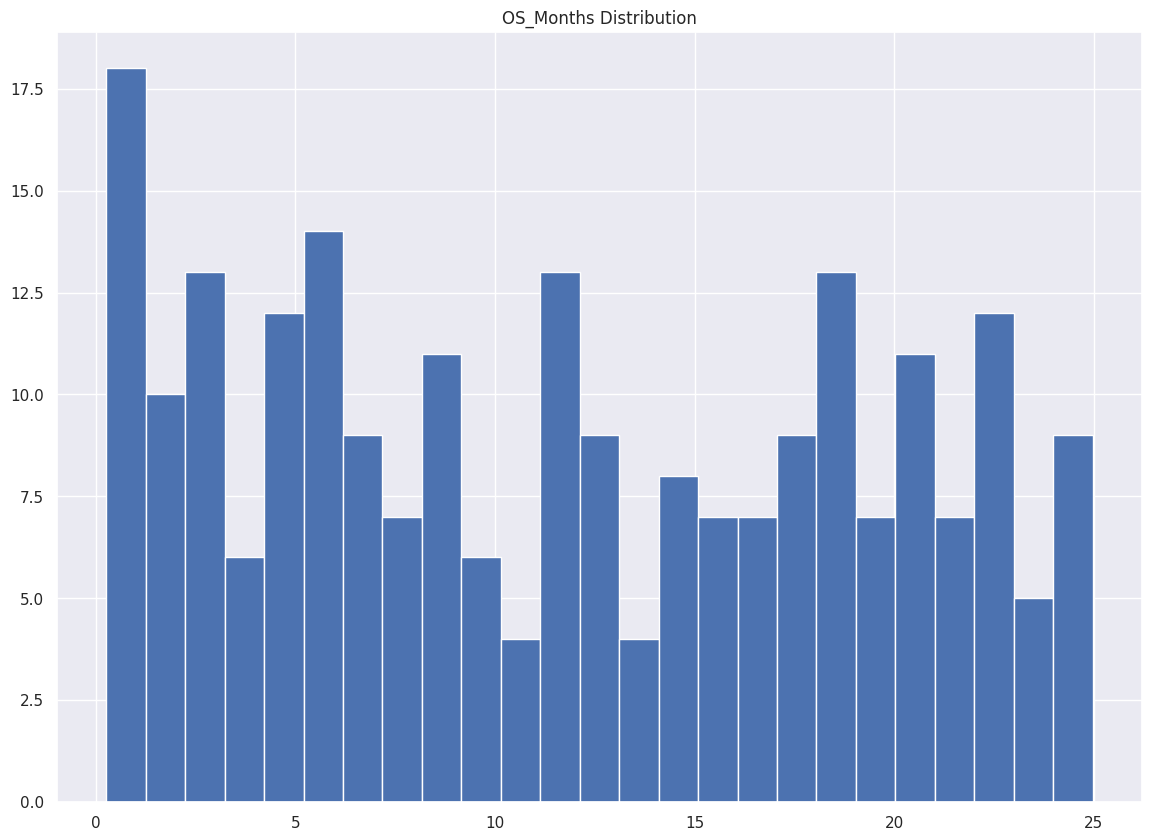

In [ ]:
plt.hist(clinical_data[clinical_data['OS_MONTHS']<25]['OS_MONTHS'], bins=25)  #

plt.title('OS_Months Distribution')
plt.show()

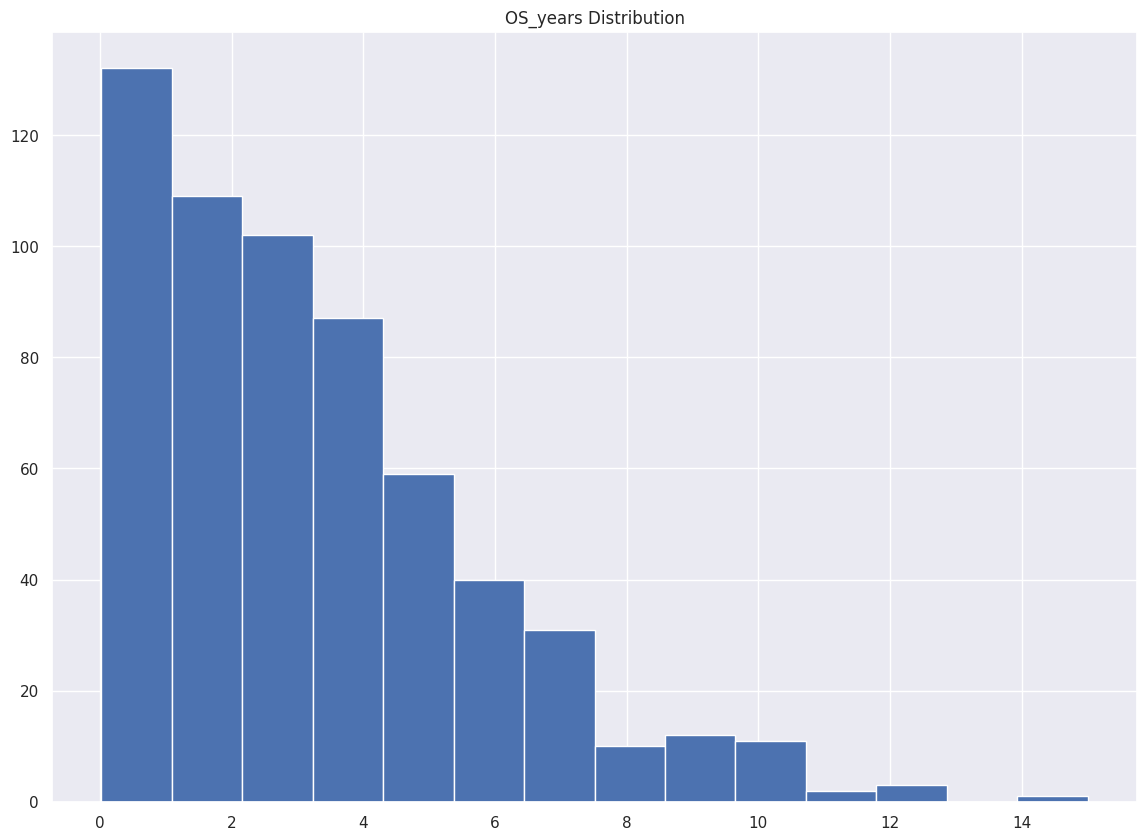

In [ ]:
plt.hist(clinical_data['OS_MONTHS']/12, bins=14)  #

plt.title('OS_years Distribution')
plt.show()

<Axes: >

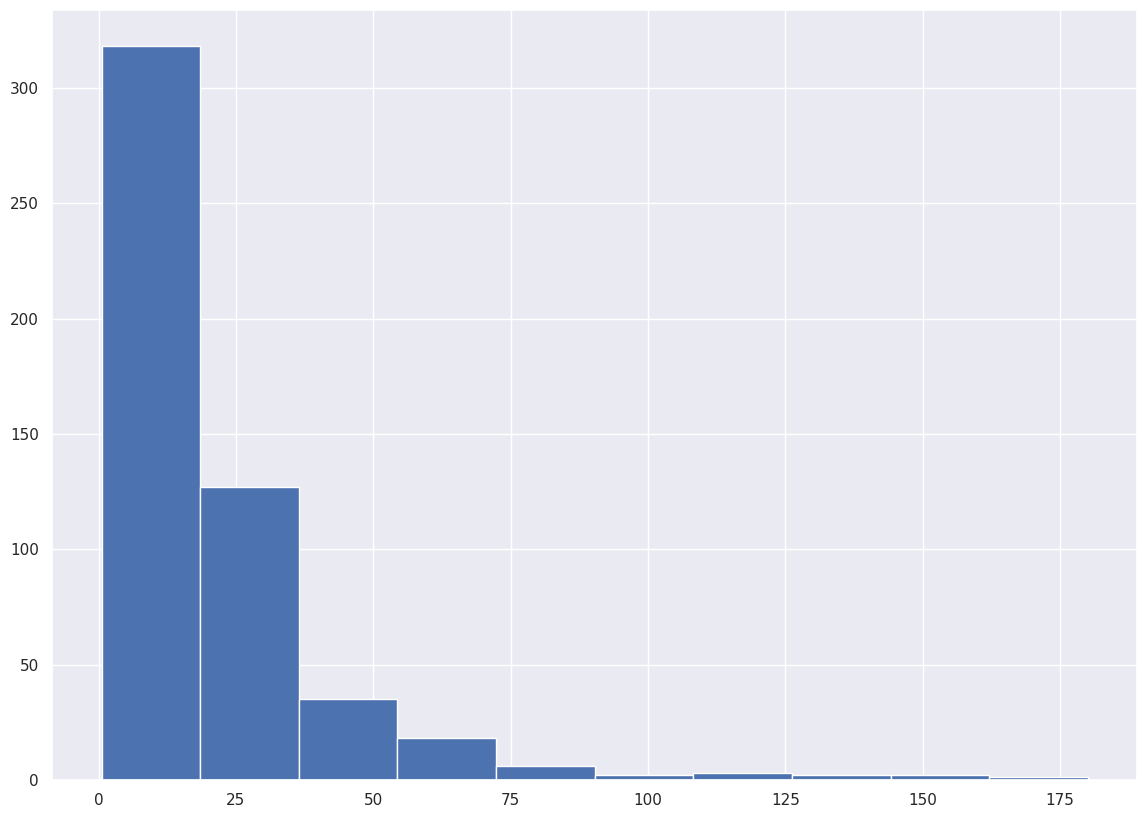

In [ ]:
clinical_data.DFS_MONTHS.hist()

<Axes: >

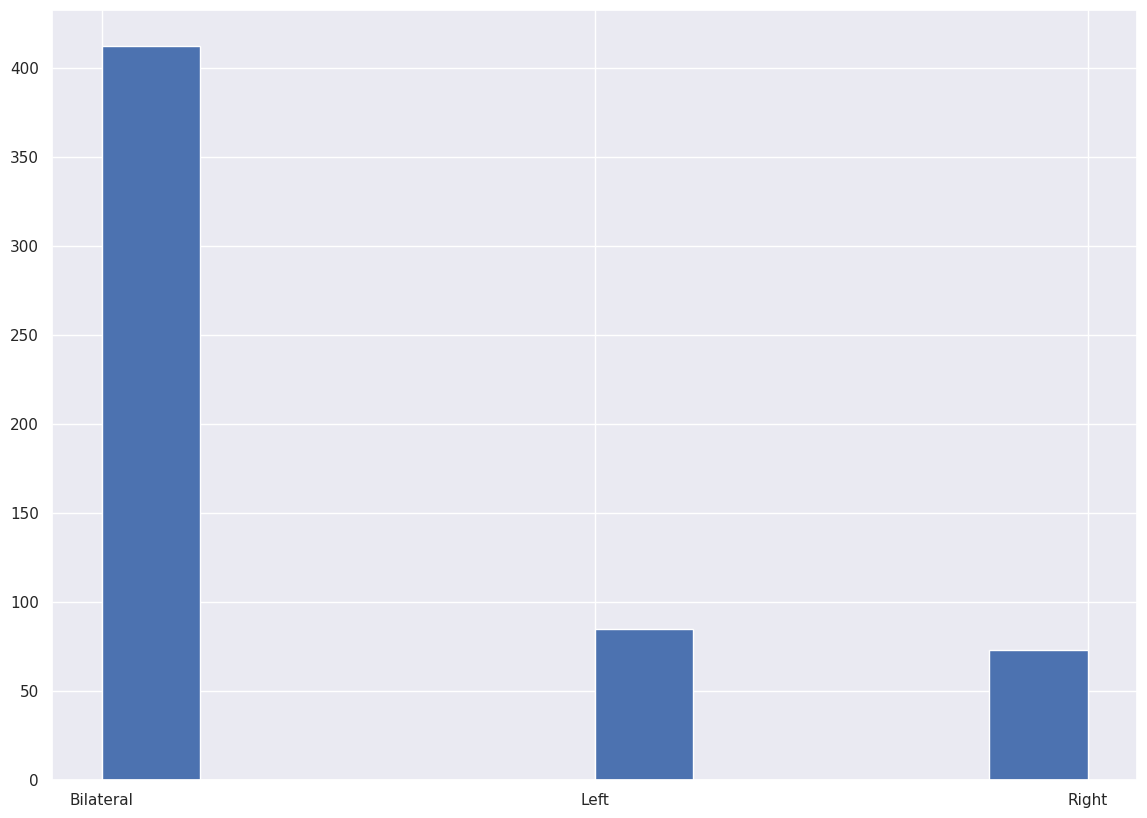

In [ ]:
clinical_data.PRIMARY_SITE.hist()

In [ ]:
clinical_data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 617 entries, 1 to 617
Data columns (total 61 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   CASE_ID                                  617 non-null    object 
 1   AGE                                      604 non-null    float64
 2   CANCER_TYPE                              617 non-null    object 
 3   CANCER_TYPE_DETAILED                     617 non-null    object 
 4   CLINICAL_STAGE                           599 non-null    object 
 5   DAYS_TO_COLLECTION                       10 non-null     float64
 6   DAYS_TO_INITIAL_PATHOLOGIC_DIAGNOSIS     604 non-null    float64
 7   DFS_MONTHS                               514 non-null    float64
 8   DFS_STATUS                               516 non-null    object 
 9   ECOG_SCORE                               132 non-null    float64
 10  ETHNICITY                                356 non-n

In [ ]:
columns_unfunc = ['OTHER_PATIENT_ID', 'OTHER_SAMPLE_ID', 'PATHOLOGY_REPORT_FILE_NAME', 'PATHOLOGY_REPORT_UUID','HISTORY_OTHER_MALIGNANCY'
                  , 'RETROSPECTIVE_COLLECTION', 'SAMPLE_INITIAL_WEIGHT', 'SEX', 'TREATMENT_OUTCOME_FIRST_COURSE', 'RADIATION_TREATMENT_ADJUVANT'
                 , 'PHARMACEUTICAL_TX_ADJUVANT', 'PROSPECTIVE_COLLECTION','OCT_EMBEDDED' ]
clinical_data.drop(columns_unfunc
                   , axis=1, inplace=True)

In [ ]:
for i, column in enumerate(clinical_data.columns):
    print(f"Column {i + 1}: {column}")
    print(clinical_data[column].unique())
    print("\n")

Column 1: CASE_ID
['TCGA-29-1777-01' 'TCGA-61-2009-01' 'TCGA-61-1899-01' 'TCGA-61-1910-01'
 'TCGA-13-0730-01' 'TCGA-29-1697-01' 'TCGA-30-1880-01' 'TCGA-61-1738-01'
 'TCGA-13-1483-01' 'TCGA-36-1581-01' 'TCGA-10-0925-01' 'TCGA-25-1877-01'
 'TCGA-25-1315-01' 'TCGA-13-1505-01' 'TCGA-24-1426-01' 'TCGA-61-2101-01'
 'TCGA-13-0891-01' 'TCGA-24-1105-01' 'TCGA-25-2400-01' 'TCGA-23-2645-01'
 'TCGA-13-0913-02' 'TCGA-13-0913-01' 'TCGA-24-1564-01' 'TCGA-09-1667-01'
 'TCGA-57-1992-01' 'TCGA-23-1113-01' 'TCGA-13-0924-01' 'TCGA-04-1649-01'
 'TCGA-30-1718-01' 'TCGA-24-2271-01' 'TCGA-09-0365-01' 'TCGA-10-0936-01'
 'TCGA-24-1553-01' 'TCGA-24-2260-01' 'TCGA-23-1022-01' 'TCGA-13-1494-01'
 'TCGA-25-1326-01' 'TCGA-09-2053-01' 'TCGA-24-1930-01' 'TCGA-24-2029-01'
 'TCGA-23-1124-01' 'TCGA-24-2295-01' 'TCGA-36-1568-01' 'TCGA-13-0765-01'
 'TCGA-04-1638-01' 'TCGA-61-2102-01' 'TCGA-30-1892-01' 'TCGA-24-1427-01'
 'TCGA-36-2540-01' 'TCGA-09-2054-01' 'TCGA-23-2084-01' 'TCGA-61-2008-01'
 'TCGA-13-0890-01' 'TCGA-29-2425-

In [ ]:
clinical_data['Survival_Group'] = pd.cut(clinical_data['OS_MONTHS'], bins=[-float('inf'), 60, float('inf')], labels=['short_term_survive', 'long_term_survive'])

In [ ]:
grouped_summary = clinical_data.groupby('Survival_Group').mean().transpose()
print(grouped_summary)

Survival_Group                        short_term_survive  long_term_survive
AGE                                            60.000000          58.133858
DAYS_TO_COLLECTION                            409.000000        1211.000000
DAYS_TO_INITIAL_PATHOLOGIC_DIAGNOSIS            0.000000           0.000000
DFS_MONTHS                                     15.167652          41.959915
ECOG_SCORE                                      0.572727           0.227273
FRACTION_GENOME_ALTERED                         0.552545           0.557350
INITIAL_PATHOLOGIC_DX_YEAR                   2004.086864        2002.354331
KARNOFSKY_PERFORMANCE_SCORE                    75.121951          76.739130
LONGEST_DIMENSION                               1.373198           1.449573
MUTATION_COUNT                                 45.864407          58.846154
OS_MONTHS                                      26.522331          86.220157
SAMPLE_COUNT                                    1.042373           1.110236
SAMPLE_TYPE_

<ipython-input-32-960ec7ef6814>:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  grouped_summary = clinical_data.groupby('Survival_Group').mean().transpose()


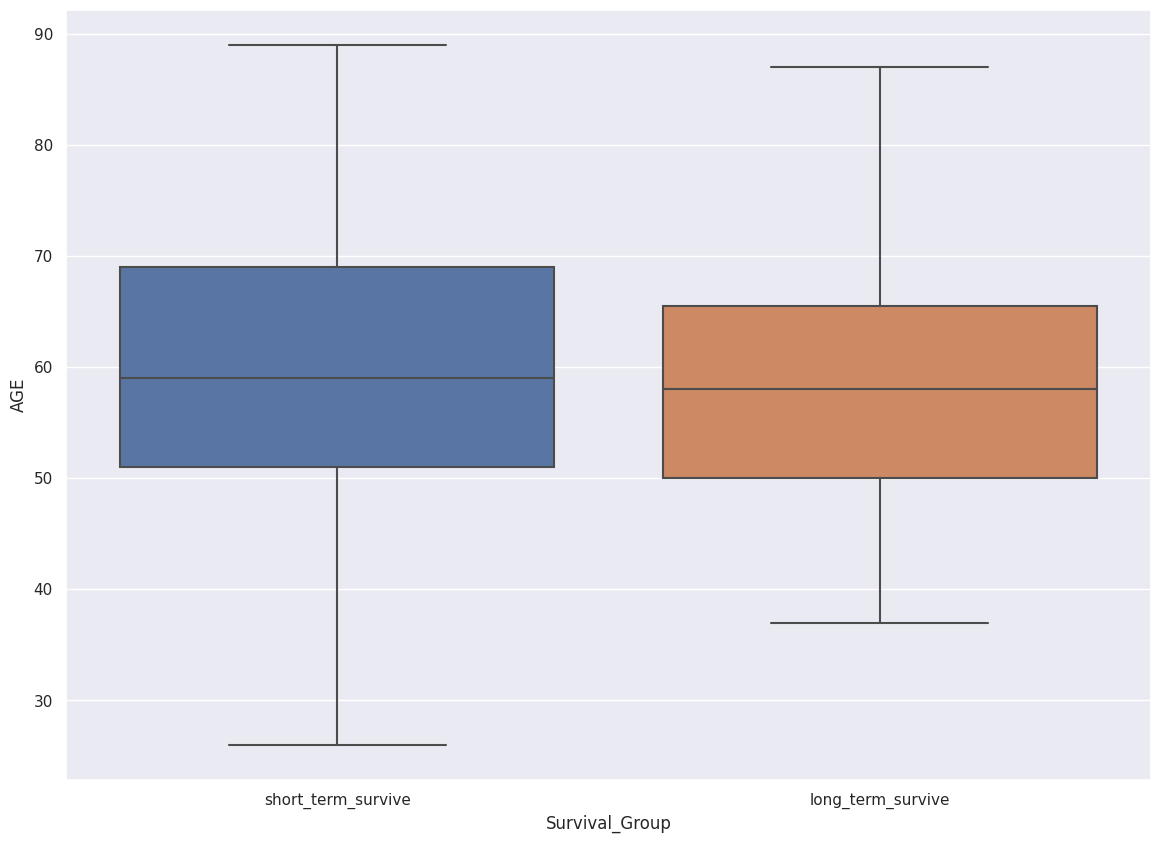

In [ ]:
# Example: Box plot of AGE by Survival_Group
sns.boxplot(x='Survival_Group', y='AGE', data=clinical_data)
plt.show()

In [ ]:
clinical_data.dropna(subset=['OS_MONTHS'], inplace=True)

In [ ]:
new_mapping_clinical_stage = {'Stage IA': 1, 'Stage IB': 2, 'Stage IC': 3, 'Stage IIA': 4, 'Stage IIB': 5,
                               'Stage IIC': 6,'Stage IIIA': 7,  'Stage IIIB': 8,
                               'Stage IIIC': 9, 'Stage IV': 10}

# Применяем новый мапинг к столбцу
clinical_data['CLINICAL_STAGE_NUM'] = clinical_data['CLINICAL_STAGE'].map(new_mapping_clinical_stage)
clinical_data[['CLINICAL_STAGE', 'CLINICAL_STAGE_NUM']].info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 599 entries, 1 to 617
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CLINICAL_STAGE      595 non-null    object 
 1   CLINICAL_STAGE_NUM  595 non-null    float64
dtypes: float64(1), object(1)
memory usage: 14.0+ KB


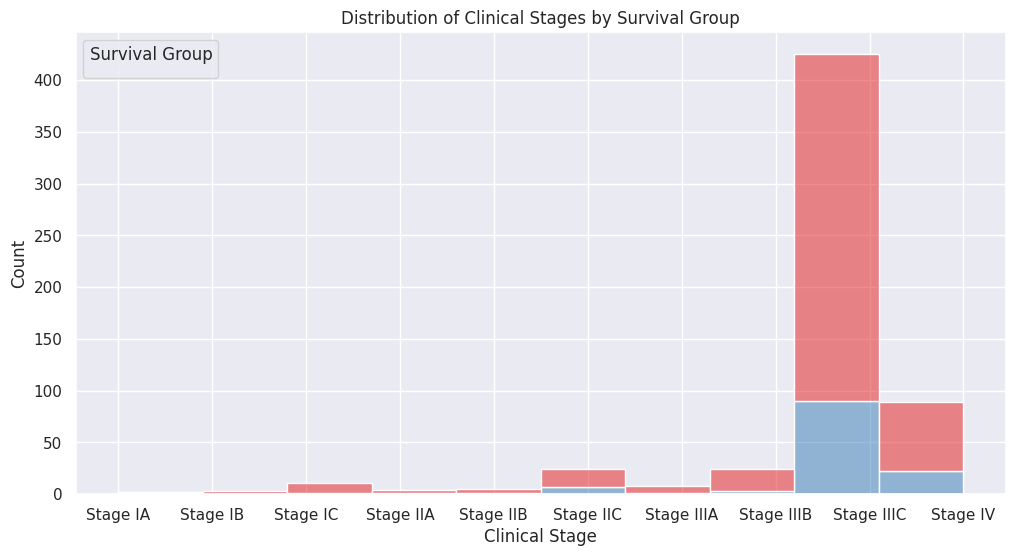

In [ ]:
# Get the original clinical stage labels in the desired order
sorted_stage_labels = [stage for stage, num in sorted(new_mapping_clinical_stage.items(), key=lambda x: x[1])]

# Plot overlapping histograms with different colors for each survival group
plt.figure(figsize=(12, 6))
sns.histplot(data=clinical_data, x='CLINICAL_STAGE_NUM', hue='Survival_Group', multiple='stack', bins=len(sorted_stage_labels), palette='Set1', alpha=0.5)
plt.xlabel('Clinical Stage')
plt.ylabel('Count')
plt.title('Distribution of Clinical Stages by Survival Group')
plt.legend(title='Survival Group')
plt.xticks(range(1, len(sorted_stage_labels) + 1), labels=sorted_stage_labels)
plt.show()

In [ ]:
clinical_data[clinical_data['CLINICAL_STAGE_NUM'].isna()]

,CASE_ID,AGE,CANCER_TYPE,CANCER_TYPE_DETAILED,CLINICAL_STAGE,DAYS_TO_COLLECTION,DAYS_TO_INITIAL_PATHOLOGIC_DIAGNOSIS,DFS_MONTHS,DFS_STATUS,ECOG_SCORE,ETHNICITY,FORM_COMPLETION_DATE,FRACTION_GENOME_ALTERED,GRADE,HISTOLOGICAL_DIAGNOSIS,HISTORY_NEOADJUVANT_TRTYN,ICD_10,ICD_O_3_HISTOLOGY,ICD_O_3_SITE,INFORMED_CONSENT_VERIFIED,INITIAL_PATHOLOGIC_DX_YEAR,IS_FFPE,JEWISH_RELIGION_HERITAGE_INDICATOR,KARNOFSKY_PERFORMANCE_SCORE,LONGEST_DIMENSION,LYMPHOVASCULAR_INVASION_INDICATOR,METHOD_OF_INITIAL_SAMPLE_PROCUREMENT,MUTATION_COUNT,NEW_TUMOR_EVENT_AFTER_INITIAL_TREATMENT,ONCOTREE_CODE,OS_MONTHS,OS_STATUS,PERFORMANCE_STATUS_TIMING,PRIMARY_SITE,RACE,RESIDUAL_TUMOR,SAMPLE_COUNT,SAMPLE_TYPE,SAMPLE_TYPE_ID,SHORTEST_DIMENSION,SOMATIC_STATUS,SPECIMEN_SECOND_LONGEST_DIMENSION,TISSUE_SOURCE_SITE,TMB_NONSYNONYMOUS,TUMOR_STATUS,TUMOR_TISSUE_SITE,VASCULAR_INVASION_INDICATOR,VIAL_NUMBER,CLINICAL_STAGE_NUM,Survival_Group
180,TCGA-30-1859-01,56.0,Ovarian Cancer,Serous Ovarian Cancer,NaN,NaN,0.0,NaN,NaN,0.0,NOT HISPANIC OR LATINO,06/02/2009,0.5967,G3,Serous Cystadenocarcinoma,No,C56.9,8441/3,C56.9,YES,2002.0,NO,NaN,NaN,1.0,NaN,Tumor resection,NaN,NaN,SOC,48.06,1:DECEASED,Post-Adjuvant Therapy,Bilateral,WHITE,NaN,1,Primary,1,0.3,Matched,0.3,30,NaN,WITH TUMOR,Ovary,NaN,A,NaN,short_term_survive
277,TCGA-57-1994-01,63.0,Ovarian Cancer,Serous Ovarian Cancer,NaN,NaN,0.0,25.00,0:DiseaseFree,NaN,NaN,06/10/2011,0.4677,NaN,Serous Cystadenocarcinoma,No,C56.9,8441/3,C56.9,YES,2004.0,NO,NaN,NaN,0.5,NaN,Tumor resection,NaN,NaN,SOC,25.00,0:LIVING,NaN,NaN,WHITE,NaN,1,Primary,1,0.4,Matched,0.5,57,NaN,NaN,Ovary,NaN,A,NaN,short_term_survive
547,TCGA-24-2293-01,47.0,Ovarian Cancer,Serous Ovarian Cancer,NaN,NaN,0.0,NaN,NaN,NaN,NaN,2/26/10,0.2485,G3,Serous Cystadenocarcinoma,No,C48.1,8441/3,C48.1,YES,1995.0,NO,NaN,NaN,1.3,NaN,Tumor resection,61.0,NaN,SOC,16.62,1:DECEASED,NaN,Right,WHITE,NaN,1,Primary,1,0.3,Matched,1.1,24,2,NaN,Omentum,NaN,A,NaN,short_term_survive
555,TCGA-04-1341-01,85.0,Ovarian Cancer,Serous Ovarian Cancer,NaN,NaN,0.0,1.08,0:DiseaseFree,NaN,NOT HISPANIC OR LATINO,3/26/09,0.7221,G3,Serous Cystadenocarcinoma,No,C56.9,8441/3,C56.9,YES,2006.0,NO,NaN,NaN,1.5,NaN,NaN,NaN,NaN,SOC,1.08,0:LIVING,NaN,NaN,WHITE,NaN,1,Primary,1,0.4,Matched,1.0,4,NaN,NaN,Ovary,NaN,A,NaN,short_term_survive


In [ ]:
clinical_data.drop('CLINICAL_STAGE'
                   , axis=1, inplace=True)

In [ ]:
filled_dataframe

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,24,25,26,27
0,2.0,1.0,530101.0,38.50,66.0,28.0,3.0,3.0,2.2,2.0,5.0,4.0,4.0,1.8,1.6,6.70,3.0,5.0,45.0,8.40,2.2,3.96,2.0,11300.0,0.0,0.0,2.0
1,1.0,1.0,534817.0,39.20,88.0,20.0,3.0,2.0,4.0,1.0,3.0,4.0,2.0,1.2,2.2,1.80,4.0,2.0,50.0,85.00,2.0,2.00,3.0,2208.0,0.0,0.0,2.0
2,2.0,1.0,530334.0,38.30,40.0,24.0,1.0,1.0,3.0,1.0,3.0,3.0,1.0,1.8,1.4,4.90,1.0,1.0,33.0,6.70,2.2,5.18,1.0,0.0,0.0,0.0,1.0
3,1.0,9.0,5290409.0,39.10,164.0,84.0,4.0,1.0,6.0,2.0,2.0,4.0,4.0,1.0,2.0,5.00,3.0,3.2,48.0,7.20,3.0,5.30,2.0,2208.0,0.0,0.0,1.0
4,2.0,1.0,530255.0,37.30,104.0,35.0,3.0,2.6,6.0,2.0,3.6,2.8,2.6,1.4,2.0,5.50,3.4,4.2,74.0,7.40,2.4,2.80,2.0,4300.0,0.0,0.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,1.0,1.0,533886.0,38.18,120.0,70.0,4.0,3.2,4.0,2.0,2.0,4.0,3.2,1.8,2.0,1.80,3.4,5.0,55.0,65.00,2.0,1.60,3.0,3205.0,0.0,0.0,2.0
296,2.0,1.0,527702.0,37.20,72.0,24.0,3.0,2.0,4.0,2.0,4.0,3.0,3.0,3.0,1.0,5.78,4.0,4.0,44.0,7.52,3.0,3.30,3.0,2208.0,0.0,0.0,1.0
297,1.0,1.0,529386.0,37.50,72.0,30.0,4.0,3.0,4.0,1.0,4.0,4.0,3.0,2.0,1.0,5.80,3.0,5.0,60.0,6.80,1.8,5.44,2.0,3205.0,0.0,0.0,2.0
298,1.0,1.0,530612.0,36.50,100.0,24.0,3.0,3.0,3.0,1.0,3.0,3.0,3.0,3.0,1.0,5.90,4.0,4.0,50.0,6.00,3.0,3.40,1.0,2208.0,0.0,0.0,1.0


In [ ]:
dataframe

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27
0,2.0,1,530101,38.5,66.0,28.0,3.0,3.0,NaN,2.0,5.0,4.0,4.0,NaN,NaN,NaN,3.0,5.0,45.0,8.4,NaN,NaN,2.0,2,11300,0,0,2
1,1.0,1,534817,39.2,88.0,20.0,NaN,NaN,4.0,1.0,3.0,4.0,2.0,NaN,NaN,NaN,4.0,2.0,50.0,85.0,2.0,2.0,3.0,2,2208,0,0,2
2,2.0,1,530334,38.3,40.0,24.0,1.0,1.0,3.0,1.0,3.0,3.0,1.0,NaN,NaN,NaN,1.0,1.0,33.0,6.7,NaN,NaN,1.0,2,0,0,0,1
3,1.0,9,5290409,39.1,164.0,84.0,4.0,1.0,6.0,2.0,2.0,4.0,4.0,1.0,2.0,5.0,3.0,NaN,48.0,7.2,3.0,5.3,2.0,1,2208,0,0,1
4,2.0,1,530255,37.3,104.0,35.0,NaN,NaN,6.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,74.0,7.4,NaN,NaN,2.0,2,4300,0,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,1.0,1,533886,NaN,120.0,70.0,4.0,NaN,4.0,2.0,2.0,4.0,NaN,NaN,NaN,NaN,NaN,5.0,55.0,65.0,NaN,NaN,3.0,2,3205,0,0,2
296,2.0,1,527702,37.2,72.0,24.0,3.0,2.0,4.0,2.0,4.0,3.0,3.0,3.0,1.0,NaN,4.0,4.0,44.0,NaN,3.0,3.3,3.0,1,2208,0,0,1
297,1.0,1,529386,37.5,72.0,30.0,4.0,3.0,4.0,1.0,4.0,4.0,3.0,2.0,1.0,NaN,3.0,5.0,60.0,6.8,NaN,NaN,2.0,1,3205,0,0,2
298,1.0,1,530612,36.5,100.0,24.0,3.0,3.0,3.0,1.0,3.0,3.0,3.0,3.0,1.0,NaN,4.0,4.0,50.0,6.0,3.0,3.4,1.0,1,2208,0,0,1


In [ ]:
clinical_data['IS_HISPANIC'] = (clinical_data['ETHNICITY'] == 'HISPANIC OR LATINO').astype(int)

In [ ]:
clinical_data['IS_VASCULAR_INVASION_INDICATOR'] = (clinical_data['VASCULAR_INVASION_INDICATOR'] == 'YES').astype(int)

In [ ]:
clinical_data['WITH_TUMOR'] = (clinical_data['TUMOR_STATUS'] == 'WITH TUMOR').astype(int)

In [ ]:
clinical_data['NEW_TUMOR_AFT_TREAT'] = (clinical_data['NEW_TUMOR_EVENT_AFTER_INITIAL_TREATMENT'] == 'YES').astype(int)

In [ ]:
clinical_data['Ashkenazi'] = (clinical_data['JEWISH_RELIGION_HERITAGE_INDICATOR'] == 'ASHKENAZI').astype(int)

In [ ]:
clinical_data['IS_LYMPHOVASCULAR_INVASION_INDICATOR'] = (clinical_data['LYMPHOVASCULAR_INVASION_INDICATOR'] == 'YES').astype(int)

In [ ]:
clinical_data.drop('LYMPHOVASCULAR_INVASION_INDICATOR'
                   , axis=1, inplace=True)

In [ ]:
columns_unfunc = ['VIAL_NUMBER', 'TMB_NONSYNONYMOUS', 'SOMATIC_STATUS', 'SAMPLE_TYPE_ID'
                  ,  'SAMPLE_COUNT', 'OS_STATUS', 'ONCOTREE_CODE', 'METHOD_OF_INITIAL_SAMPLE_PROCUREMENT'
                  , 'IS_FFPE', 'INITIAL_PATHOLOGIC_DX_YEAR', 'INFORMED_CONSENT_VERIFIED'
                 , 'ICD_O_3_SITE', 'ICD_O_3_HISTOLOGY', 'HISTORY_NEOADJUVANT_TRTYN'
                 , 'HISTOLOGICAL_DIAGNOSIS', 'FORM_COMPLETION_DATE', 'DAYS_TO_INITIAL_PATHOLOGIC_DIAGNOSIS'
                 , 'DAYS_TO_COLLECTION', 'CANCER_TYPE_DETAILED', 'CANCER_TYPE']
clinical_data.drop(columns_unfunc
                   , axis=1, inplace=True)

In [ ]:
clinical_data.drop('TISSUE_SOURCE_SITE'
                   , axis=1, inplace=True)

In [ ]:
# Specify the columns you want to convert
# columns_to_convert = ['CLINICAL_STAGE', 'DFS_STATUS', 'NEW_TUMOR_EVENT_AFTER_INITIAL_TREATMENT',
#                        'PERFORMANCE_STATUS_TIMING', 'LYMPHOVASCULAR_INVASION_INDICATOR',
#                        'PHARMACEUTICAL_TX_ADJUVANT', 'PRIMARY_SITE', 'RACE', 'RESIDUAL_TUMOR', 'TUMOR_TISSUE_SITE']

columns_to_convert = ['TUMOR_TISSUE_SITE', 'SAMPLE_TYPE', 'RACE', 'PRIMARY_SITE'
                     , 'PERFORMANCE_STATUS_TIMING', 'ICD_10', 'ECOG_SCORE', 'DFS_STATUS', 'GRADE'
                     ,'RESIDUAL_TUMOR']


# Apply one-hot encoding to the specified columns
clinical_data = pd.get_dummies(clinical_data, columns=columns_to_convert)

# Display the resulting DataFrame
#clinical_data.drop(columns_to_convert, axis=1, inplace=True)


In [ ]:
corrected_columns = ['ETHNICITY', 'VASCULAR_INVASION_INDICATOR', 'TUMOR_STATUS'
                     ,'NEW_TUMOR_EVENT_AFTER_INITIAL_TREATMENT', 'JEWISH_RELIGION_HERITAGE_INDICATOR'
                    ,]
clinical_data.drop(corrected_columns, axis=1, inplace=True)

In [ ]:
clinical_data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 599 entries, 1 to 617
Data columns (total 57 columns):
 #   Column                                           Non-Null Count  Dtype   
---  ------                                           --------------  -----   
 0   CASE_ID                                          599 non-null    object  
 1   AGE                                              599 non-null    float64 
 2   CLINICAL_STAGE                                   595 non-null    object  
 3   DFS_MONTHS                                       514 non-null    float64 
 4   FRACTION_GENOME_ALTERED                          582 non-null    float64 
 5   KARNOFSKY_PERFORMANCE_SCORE                      87 non-null     float64 
 6   LONGEST_DIMENSION                                561 non-null    float64 
 7   MUTATION_COUNT                                   314 non-null    float64 
 8   OS_MONTHS                                        599 non-null    float64 
 9   SHORTEST_DIMENSION   

In [ ]:
clinical_data.sum()

<ipython-input-75-1ba9a308a2da>:1: FutureWarning: The default value of numeric_only in DataFrame.sum is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  clinical_data.sum()


CASE_ID                                            TCGA-29-1777-01TCGA-61-2009-01TCGA-61-1899-01T...
AGE                                                                                          35703.0
DFS_MONTHS                                                                                  10957.66
FRACTION_GENOME_ALTERED                                                                     322.1817
KARNOFSKY_PERFORMANCE_SCORE                                                                   6610.0
LONGEST_DIMENSION                                                                              779.3
MUTATION_COUNT                                                                               15414.0
OS_MONTHS                                                                                    23468.5
SHORTEST_DIMENSION                                                                            241.35
SPECIMEN_SECOND_LONGEST_DIMENSION                                                          

In [ ]:
clinical_data.to_csv('/content/drive/My Drive/Python_projects/OvarianCancer/Results/clinical_data_prepared.csv', index=True)

OSError: ignored

In [ ]:
group_means = clinical_data.groupby('Survival_Group')[['DFS_MONTHS', 'FRACTION_GENOME_ALTERED', 'KARNOFSKY_PERFORMANCE_SCORE'
                                           ,'LONGEST_DIMENSION', 'MUTATION_COUNT', 'SHORTEST_DIMENSION'
                                           , 'SPECIMEN_SECOND_LONGEST_DIMENSION', 'CLINICAL_STAGE_NUM' ]].transform('mean')

# Fill NaN values with the corresponding group mean
clinical_data[['DFS_MONTHS', 'FRACTION_GENOME_ALTERED', 'KARNOFSKY_PERFORMANCE_SCORE'
    ,'LONGEST_DIMENSION', 'MUTATION_COUNT', 'SHORTEST_DIMENSION'
    , 'SPECIMEN_SECOND_LONGEST_DIMENSION', 'CLINICAL_STAGE_NUM' ]] = clinical_data[['DFS_MONTHS', 'FRACTION_GENOME_ALTERED', 'KARNOFSKY_PERFORMANCE_SCORE'
                                               ,'LONGEST_DIMENSION', 'MUTATION_COUNT', 'SHORTEST_DIMENSION'
                                               , 'SPECIMEN_SECOND_LONGEST_DIMENSION', 'CLINICAL_STAGE_NUM' ]].fillna(group_means)

## Classificaton

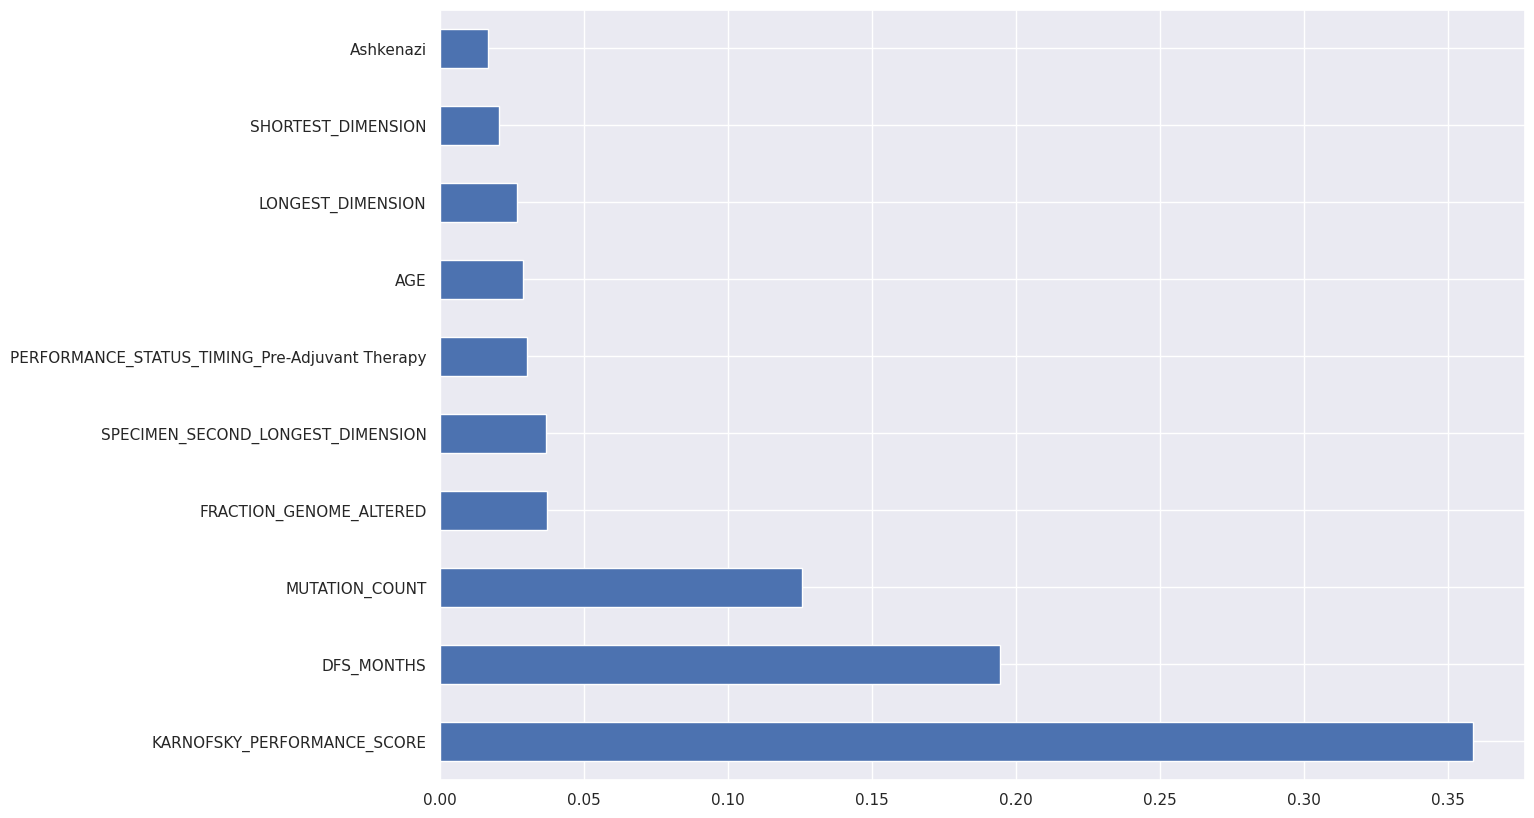

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Example: Random Forest for feature importance
X = clinical_data.drop(['OS_MONTHS',
                        'CASE_ID', 'Survival_Group'], axis=1)  # Features excluding the target variable and grouping column
y = clinical_data['Survival_Group']

model = RandomForestClassifier(random_state=42)
model.fit(X, y)

feature_importance = pd.Series(model.feature_importances_, index=X.columns)
feature_importance.nlargest(10).plot(kind='barh')
plt.show()

In [ ]:
# Install necessary libraries
!pip install scikit-learn interpret imblearn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.9/16.9 MB 52.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 57.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 65.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.4/6.4 MB 65.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 25.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 758.0/758.0 kB 55.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 533.5/533.5 kB 45.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.3/115.3 kB 14.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 247.1/247.1 kB 28.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 79.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 17.0 MB/s eta 0:00:00
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.w

In [ ]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import RandomOverSampler

In [ ]:
from interpret.glassbox import (LogisticRegression,
                                ClassificationTree)
from interpret import show
from sklearn.metrics import f1_score, accuracy_score

# Split the data for evaluation
# Example: Random Forest for feature importance
X = clinical_data.drop(['OS_MONTHS',
                        'CASE_ID', 'Survival_Group'], axis=1)  # Features excluding the target variable and grouping column
y = clinical_data['Survival_Group']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=2021)
print(X_train.shape)
print(X_test.shape)
# Oversample the train data
#X_train, y_train = data_loader.oversample(X_train, y_train)
oversample = RandomOverSampler(sampling_strategy='minority')
# Convert to numpy and oversample
x_np = X_train.to_numpy()
y_np = y_train.to_numpy()
x_np, y_np = oversample.fit_resample(x_np, y_np)
# Convert back to pandas
X_train = pd.DataFrame(x_np, columns=X_train.columns)
y_train = pd.Series(y_np, name=y_train.name)
print("After oversampling:", X_train.shape)

# %% Fit logistic regression model
lr = LogisticRegression(random_state=2021, feature_names=X_train.columns, penalty='l1', solver='liblinear')
lr.fit(X_train, y_train)
print("Training finished.")

# %% Evaluate logistic regression model
y_pred = lr.predict(X_test)
print(f"F1 Score {f1_score(y_test, y_pred, average='macro')}")
print(f"Accuracy {accuracy_score(y_test, y_pred)}")

(479, 53)
(120, 53)
After oversampling: (758, 53)
Training finished.
F1 Score 0.7537619699042408
Accuracy 0.8


In [ ]:
# %% Explain global logistic regression model
lr_global = lr.explain_global(name='Logistic Regression')
show(lr_global)

In [ ]:
# %% Explain local prediction
lr_local = lr.explain_local(X_test[:100], y_test[:100], name='Logistic Regression')
show(lr_local)


In [ ]:
methyl.columns = [col[:len(col)-13] for col in methyl.columns]

In [ ]:
methyl.head()

,TCGA-29-1696-01,TCGA-24-2267-01,TCGA-29-1692-01,TCGA-24-1843-01,TCGA-20-1682-01,TCGA-25-1319-01,TCGA-24-2254-01,TCGA-04-1542-01,TCGA-61-1728-01,TCGA-13-0723-01,TCGA-29-1781-01,TCGA-29-1705-01,TCGA-24-1104-01,TCGA-30-1887-01,TCGA-36-1570-01,TCGA-13-0720-01,TCGA-13-1487-01,TCGA-13-0910-01,TCGA-24-0980-01,TCGA-23-1122-01,TCGA-23-1027-01,TCGA-29-2434-01,TCGA-04-1646-01,TCGA-30-1866-01,TCGA-23-1030-01,TCGA-25-1627-01,TCGA-04-1652-01,TCGA-13-0760-01,TCGA-42-2589-01,TCGA-20-0996-01,TCGA-36-2544-01,TCGA-72-4236-01,TCGA-04-1360-01,TCGA-24-2036-01,TCGA-13-0768-01,TCGA-36-1577-01,TCGA-13-0889-01,TCGA-24-2261-01,TCGA-13-0906-01,TCGA-61-2098-01,TCGA-24-1471-01,TCGA-36-1581-01,TCGA-59-2363-01,TCGA-61-1911-01,TCGA-13-0724-01,TCGA-10-0927-01,TCGA-20-1684-01,TCGA-31-1951-01,TCGA-13-1411-01,TCGA-24-1425-01,TCGA-20-1683-01,TCGA-09-1669-01,TCGA-23-1107-01,TCGA-30-1718-01,TCGA-25-2399-01,TCGA-30-1892-01,TCGA-09-1665-01,TCGA-30-1880-01,TCGA-13-1500-01,TCGA-04-1332-01,TCGA-13-2066-01,TCGA-61-2087-01,TCGA-20-0990-01,TCGA-04-1343-01,TCGA-13-1497-01,TCGA-24-1424-01,TCGA-13-0714-01,TCGA-29-1763-01,TCGA-09-1674-01,TCGA-24-1567-01,TCGA-13-0755-01,TCGA-59-2348-01,TCGA-04-1367-01,TCGA-36-2540-01,TCGA-25-2404-01,TCGA-09-2043-01,TCGA-25-1323-01,TCGA-13-0885-01,TCGA-36-2538-01,TCGA-24-2297-01,TCGA-04-1517-01,TCGA-61-1995-01,TCGA-04-1335-01,TCGA-25-1878-01,TCGA-20-1687-01,TCGA-24-1470-01,TCGA-61-1743-01,TCGA-29-2414-01,TCGA-25-1322-01,TCGA-24-1845-01,TCGA-13-0799-01,TCGA-24-1558-01,TCGA-24-0970-01,TCGA-13-1481-01,TCGA-23-1117-01,TCGA-29-1764-01,TCGA-24-2029-01,TCGA-25-1635-01,TCGA-24-2271-01,TCGA-24-2280-01,TCGA-23-1809-01,TCGA-23-1031-01,TCGA-23-1114-01,TCGA-61-1727-01,TCGA-61-2613-01,TCGA-13-1410-01,TCGA-24-1564-01,TCGA-30-1859-01,TCGA-13-1491-01,TCGA-10-0926-01,TCGA-36-2534-01,TCGA-23-2078-01,TCGA-61-2109-01,TCGA-25-2409-01,TCGA-61-2017-01,TCGA-13-1482-01,TCGA-09-2056-01,TCGA-13-1494-01,TCGA-61-1906-01,TCGA-29-1711-01,TCGA-04-1655-01,TCGA-24-2030-01,TCGA-24-1614-01,TCGA-72-4234-01,TCGA-20-1685-01,TCGA-29-1774-01,TCGA-24-1852-01,TCGA-25-1313-01,TCGA-09-2054-01,TCGA-31-1955-01,TCGA-59-2354-01,TCGA-13-1504-01,TCGA-31-1946-01,TCGA-10-0931-01,TCGA-13-1510-01,TCGA-13-0894-01,TCGA-57-1584-01,TCGA-13-0890-01,TCGA-59-2350-01,TCGA-24-1103-01,TCGA-04-1648-01,TCGA-09-2053-01,TCGA-29-1699-01,TCGA-09-0367-01,TCGA-13-0795-01,TCGA-13-1499-01,TCGA-23-1110-01,TCGA-24-1428-01,TCGA-61-2009-01,TCGA-29-1691-01,TCGA-04-1361-01,TCGA-29-2428-01,TCGA-24-2289-01,TCGA-13-0801-01,TCGA-25-2393-01,TCGA-23-1021-01,TCGA-72-4231-01,TCGA-23-1026-01,TCGA-04-1371-01,TCGA-61-2612-01,TCGA-24-1920-01,TCGA-24-1474-01,TCGA-24-1426-01,TCGA-31-1956-01,TCGA-24-2020-01,TCGA-36-1568-01,TCGA-24-2260-01,TCGA-04-1519-01,TCGA-25-2391-01,TCGA-23-2079-01,TCGA-13-1484-01,TCGA-36-2545-01,TCGA-23-2077-01,TCGA-23-1120-01,TCGA-24-1565-01,TCGA-13-1509-01,TCGA-23-1022-01,TCGA-13-0893-01,TCGA-25-1634-01,TCGA-29-1702-01,TCGA-24-1603-01,TCGA-61-1741-01,TCGA-13-1506-01,TCGA-13-0905-01,TCGA-04-1362-01,TCGA-61-1721-01,TCGA-24-2288-01,TCGA-72-4238-01,TCGA-61-2012-01,TCGA-57-1585-01,TCGA-13-0916-01,TCGA-09-1670-01,TCGA-57-1994-01,TCGA-23-1123-01,TCGA-24-1552-01,TCGA-23-2643-01,TCGA-25-1626-01,TCGA-23-1111-01,TCGA-30-1853-01,TCGA-24-1548-01,TCGA-13-0888-01,TCGA-24-1419-01,TCGA-61-2095-01,TCGA-24-1846-01,TCGA-09-2044-01,TCGA-25-1631-01,TCGA-29-2427-01,TCGA-29-1695-01,TCGA-61-2008-01,TCGA-24-1549-01,TCGA-25-2401-01,TCGA-09-2050-01,TCGA-13-0802-01,TCGA-42-2593-01,TCGA-29-1761-01,TCGA-13-0923-01,TCGA-24-2023-01,TCGA-13-1485-01,TCGA-29-1783-01,TCGA-29-1762-01,TCGA-57-1582-01,TCGA-13-0803-01,TCGA-61-1722-01,TCGA-36-2547-01,TCGA-13-0793-01,TCGA-36-2537-01,TCGA-72-4241-01,TCGA-29-1707-01,TCGA-72-4233-01,TCGA-25-1623-01,TCGA-04-1364-01,TCGA-23-1121-01,TCGA-25-2042-01,TCGA-36-2543-01,TCGA-61-1913-01,TCGA-13-1404-01,TCGA-61-1917-01,TCGA-61-2110-01,TCGA-61-2111-01,TCGA-04-1342-01,TCGA-23-1024-01,TCGA-13-0727-01,TCGA-36-2539-01,TCGA-13-1512-01,TCGA-24-1923-01,TCGA-09-0365-01,TCGA-13-1819-01,TCGA-29-1768-01,TCGA-13-0765-01,TCGA-13-0903-01

In [ ]:
gene_expression.columns = [col[:len(col)-1] for col in gene_expression.columns]

In [ ]:
gene_expression.head()

,TCGA-10-0933-01,TCGA-23-1024-01,TCGA-13-0886-01,TCGA-29-1769-01,TCGA-13-1505-01,TCGA-61-1736-01,TCGA-61-1737-01,TCGA-25-1871-01,TCGA-29-1705-01,TCGA-24-1104-01,TCGA-13-0720-01,TCGA-61-1728-01,TCGA-WR-A838-01,TCGA-23-1122-01,TCGA-13-1487-01,TCGA-23-1027-01,TCGA-29-1774-01,TCGA-30-1866-01,TCGA-23-1030-01,TCGA-25-1627-01,TCGA-13-1410-01,TCGA-24-1564-01,TCGA-10-0926-01,TCGA-13-1510-01,TCGA-31-1956-01,TCGA-24-2020-01,TCGA-23-1028-01,TCGA-13-1407-01,TCGA-04-1655-01,TCGA-09-1661-01,TCGA-24-1416-01,TCGA-61-1911-01,TCGA-61-1995-01,TCGA-10-0927-01,TCGA-20-1684-01,TCGA-31-1951-01,TCGA-13-1411-01,TCGA-24-1425-01,TCGA-09-0367-01,TCGA-30-1718-01,TCGA-20-1687-01,TCGA-61-2094-01,TCGA-61-1743-01,TCGA-30-1892-01,TCGA-09-1665-01,TCGA-13-0801-01,TCGA-04-1343-01,TCGA-61-2092-01,TCGA-5X-AA5U-01,TCGA-61-1740-01,TCGA-09-1674-01,TCGA-61-2088-01,TCGA-24-1567-01,TCGA-25-1633-01,TCGA-23-2084-01,TCGA-59-2348-01,TCGA-OY-A56P-01,TCGA-24-1544-01,TCGA-04-1338-01,TCGA-36-1576-01,TCGA-13-0885-01,TCGA-13-0913-01,TCGA-13-0724-01,TCGA-09-1669-01,TCGA-20-1683-01,TCGA-23-1107-01,TCGA-13-0795-01,TCGA-25-2399-01,TCGA-29-1703-01,TCGA-24-1560-01,TCGA-24-2289-01,TCGA-61-1725-01,TCGA-25-1632-01,TCGA-13-1488-01,TCGA-24-2036-01,TCGA-13-1497-01,TCGA-59-2354-01,TCGA-24-1474-01,TCGA-24-1426-01,TCGA-13-1496-01,TCGA-13-0890-01,TCGA-04-1514-01,TCGA-36-1577-01,TCGA-59-2350-01,TCGA-29-A5NZ-01,TCGA-61-2098-01,TCGA-23-2077-01,TCGA-23-1120-01,TCGA-24-1565-01,TCGA-24-1423-01,TCGA-61-1900-01,TCGA-29-1781-01,TCGA-20-1685-01,TCGA-09-2054-01,TCGA-25-1313-01,TCGA-13-0760-01,TCGA-10-0931-01,TCGA-13-0768-01,TCGA-3P-A9WA-01,TCGA-24-1545-01,TCGA-13-0906-01,TCGA-13-1482-01,TCGA-36-1581-01,TCGA-29-1711-01,TCGA-13-1499-01,TCGA-23-1023-01,TCGA-29-2428-01,TCGA-24-1844-01,TCGA-25-1635-01,TCGA-23-1114-01,TCGA-OY-A56Q-01,TCGA-31-1946-01,TCGA-23-2078-01,TCGA-61-2109-01,TCGA-57-1584-01,TCGA-25-2409-01,TCGA-04-1347-01,TCGA-36-1568-01,TCGA-09-2056-01,TCGA-24-2261-01,TCGA-24-1471-01,TCGA-13-0893-01,TCGA-25-1634-01,TCGA-25-1870-01,TCGA-13-0797-01,TCGA-31-1959-01,TCGA-57-1993-01,TCGA-13-1409-01,TCGA-09-1668-01,TCGA-13-1477-01,TCGA-24-1418-01,TCGA-13-0887-01,TCGA-13-2060-01,TCGA-24-2288-01,TCGA-29-1784-01,TCGA-57-1585-01,TCGA-13-0916-01,TCGA-09-1670-01,TCGA-57-1994-01,TCGA-23-1123-01,TCGA-24-0968-01,TCGA-25-1321-01,TCGA-24-1930-01,TCGA-29-1693-01,TCGA-30-1853-01,TCGA-61-2016-01,TCGA-23-1118-01,TCGA-24-1604-01,TCGA-23-1109-01,TCGA-25-1631-01,TCGA-13-0897-01,TCGA-24-0975-01,TCGA-61-1738-01,TCGA-61-2008-01,TCGA-24-1549-01,TCGA-25-2401-01,TCGA-29-1761-01,TCGA-09-2045-01,TCGA-29-2425-01,TCGA-24-1551-01,TCGA-13-1498-01,TCGA-25-1316-01,TCGA-25-1320-01,TCGA-30-1891-01,TCGA-24-1434-01,TCGA-13-1507-01,TCGA-25-1623-01,TCGA-04-1364-01,TCGA-25-2042-01,TCGA-13-1512-01,TCGA-24-1923-01,TCGA-13-1404-01,TCGA-61-2102-01,TCGA-VG-A8LO-01,TCGA-04-1356-01,TCGA-29-1701-01,TCGA-13-0900-01,TCGA-29-1768-01,TCGA-57-1583-01,TCGA-13-0765-01,TCGA-24-2298-01,TCGA-61-2111-01,TCGA-29-1696-01,TCGA-24-2267-01,TCGA-13-0727-01,TCGA-20-1682-01,TCGA-13-0911-01,TCGA-20-0991-01,TCGA-57-1586-01,TCGA-24-1417-01,TCGA-24-1464-01,TCGA-25-2397-01,TCGA-13-1485-01,TCGA-30-1857-01,TCGA-25-2400-01,TCGA-29-1762-01,TCGA-57-1582-01,TCGA-23-1113-01,TCGA-24-1552-01,TCGA-25-2396-01,TCGA-25-1626-01,TCGA-29-1690-01,TCGA-25-1315-01,TCGA-13-0884-01,TCGA-09-1659-01,TCGA-25-2392-01,TCGA-25-1312-01,TCGA-13-0888-01,TCGA-29-1776-01,TCGA-13-1495-01,TCGA-24-1846-01,TCGA-09-2044-01,TCGA-13-1483-01,TCGA-31-1953-01,TCGA-10-0934-01,TCGA-23-1111-01,TCGA-59-2355-01,TCGA-04-1331-01,TCGA-24-1556-01,TCGA-36-1569-01,TCGA-24-1557-01,TCGA-61-2002-01,TCGA-61-1914-01,TCGA-13-0804-01,TCGA-13-1408-01,TCGA-24-0979-01,TCGA-24-2254-01,TCGA-25-1319-01,TCGA-04-1341-01,TCGA-25-1328-01,TCGA-24-1105-01,TCGA-61-1907-01,TCGA-61-2110-01,TCGA-25-1625-01,TCGA-24-1843-01,TCGA-24-1849-01,TCGA-29-1763-01,TCGA-04-1536-01,TCGA-24-2026-01,TCGA-61-1918-01,TCGA-24-1427-01,TCGA-24-2290-01,TCGA-24-1430-01,TCGA-24-1431-01,TCGA-13-0726-01,TCGA-24-2297-01,TCGA-04-1517-01,TCGA-59-2351-01,TCGA-25-1314-01,TCGA-13-1506-01

In [ ]:
# Get the common columns
common_columns = set(methyl.columns) & set(gene_expression.columns)

# Get the number of common columns
num_common_columns = len(common_columns)

# Print the result
print(f'Number of common columns: {num_common_columns}')

Number of common columns: 412


So we have data for 412 users.

In [ ]:
different_columns = set(methyl.columns) ^ set(gene_expression.columns)

# Print the different column names
print(f'Different column names: {different_columns}')

Different column names: {'TCGA-04-1335-01', 'TCGA-04-1346-01', 'TCGA-5X-AA5U-01', 'TCGA-13-0910-01', 'TCGA-04-1349-01', 'TCGA-20-0996-01', 'TCGA-04-1371-01', 'TCGA-42-2590-01', 'TCGA-36-2542-01', 'TCGA-42-2582-01', 'TCGA-13-0751-01', 'TCGA-04-1654-01', 'TCGA-29-2436-01', 'TCGA-04-1367-01', 'TCGA-23-1031-01', 'TCGA-61-1906-01', 'TCGA-04-1638-01', 'TCGA-13-0755-01', 'TCGA-13-1504-01', 'TCGA-24-2260-01', 'TCGA-36-2543-01', 'TCGA-42-2589-01', 'TCGA-23-2649-01', 'TCGA-13-0921-01', 'TCGA-23-1121-01', 'TCGA-09-2050-01', 'TCGA-13-0761-01', 'TCGA-61-2613-01', 'TCGA-36-2544-01', 'TCGA-25-1325-01', 'TCGA-04-1652-01', 'TCGA-13-1494-01', 'TCGA-30-1859-01', 'TCGA-23-2641-01', 'TCGA-10-0925-01', 'TCGA-36-2537-01', 'TCGA-29-1704-01', 'TCGA-04-1644-01', 'TCGA-72-4241-01', 'TCGA-30-1869-01', 'TCGA-29-1692-01', 'TCGA-13-0803-01', 'TCGA-24-1852-01', 'TCGA-13-0757-01', 'TCGA-25-2408-01', 'TCGA-23-2072-01', 'TCGA-61-1722-01', 'TCGA-3P-A9WA-01', 'TCGA-23-2643-01', 'TCGA-04-1360-01', 'TCGA-04-1369-01', 'TCGA-

## Methylation status choosing best

In [ ]:
# Transpose df1
df1_transposed = methyl.transpose()

In [ ]:
df1_transposed.sum()

<ipython-input-106-cec89a4a61df>:1: FutureWarning: The default value of numeric_only in DataFrame.sum is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  df1_transposed.sum()


cg04672450    0.007974754980978810.02239733044781270.0171285...
cg14324200    0.01320203884544290.020087036966360.0741244045...
cg04485075    0.01611311122482540.01835430998137430.01699525...
cg19923810                                                    0
cg21832150    0.01632394139114680.01825470258837110.01827804...
                                    ...                        
cg22415432                                                    0
cg13056210                                                    0
cg15812957                                                    0
cg21825364                                                    0
cg23654549                                                    0
Length: 20432, dtype: object

In [ ]:
df1_transposed.iloc[-25:,-25:]

,cg06532147,cg15082782,cg12572939,cg11854877,cg06306751,cg26116400,cg21697779,cg25893483,cg03595428,cg24341236,cg12324831,cg00618396,cg00547789,cg02298008,cg21248478,cg06659128,cg07311845,cg03515901,cg08455548,cg22415432,cg20401549,cg13056210,cg15812957,cg21825364,cg23654549
TCGA-61-2018-01,NaN,NaN,NaN,NaN,0.138066,0.135292,0.361526,0.1385932,0.1731098,NaN,0.05556634,0.2242498,0.04988931,0.1813101,0.1220447,0.1149249,0.02964549,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TCGA-24-2262-01,NaN,NaN,NaN,NaN,NaN,0.05760331,0.2131431,0.1653315,0.05569591,NaN,0.06355174,0.3463574,0.02026726,0.06269214,0.06040987,0.129966,0.08991045,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TCGA-29-1694-01,NaN,NaN,NaN,NaN,NaN,0.08040711,0.1501222,NaN,0.1297313,NaN,0.1038245,0.253707,0.03377368,0.2248062,0.09326375,0.1877036,0.03789719,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TCGA-61-2092-01,NaN,NaN,NaN,NaN,0.08554263,0.448851,0.5380918,0.7063245,0.6562606,NaN,0.3615972,0.6490724,0.7944931,0.9220544,0.04999614,0.05432073,0.02100251,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TCGA-61-2104-01,NaN,NaN,NaN,NaN,0.6066394,0.06612719,0.245057,0.06989883,0.09879301,NaN,0.03729587,0.1528254,0.03507974,0.06669537,0.02522284,0.09806007,0.02399521,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TCGA-24-1422-01,NaN,NaN,NaN,NaN,0.4086399,0.1367827,0.3296691,NaN,0.3465678,NaN,0.1707176,0.3550372,0.1535243,0.1246804,NaN,0.1954261,0.1251705,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TCGA-09-2049-01,NaN,NaN,NaN,NaN,NaN,0.5193968,0.5113008,0.603043,0.6562044,NaN,0.2528603,0.6229964,0.4107585,0.5352235,0.2490071,0.2726293,0.2630018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TCGA-24-2035-01,NaN,NaN,NaN,NaN,NaN,0.4432464,0.4212551,0.357225,0.3324916,NaN,0.2409016,0.4948462,0.1481349,0.1856398,0.04666574,0.1836146,0.1531275,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TCGA-24-1553-01,NaN,NaN,NaN,NaN,NaN,0.1189868,0.293212,0.1334056,0.2479802,NaN,0.1258534,0.3348257,0.07149629,0.1346522,0.1221495,0.2285083,0.05408811,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TCGA-61-2614-01,NaN,NaN,NaN,NaN,NaN,0.1379883,0.3091215,0.1541527,0.3313707,NaN,0.2326709,0.3181285,0.0897133,0.1173188,0.1808031,0.2231821,0.09075779,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df1_transposed = df1_transposed.astype(float)

In [ ]:
needed = df1_transposed.sum()

In [ ]:
needed != 0

cg04672450     True
cg14324200     True
cg04485075     True
cg19923810    False
cg21832150     True
              ...  
cg20401549     True
cg13056210    False
cg15812957    False
cg21825364    False
cg23654549    False
Length: 27578, dtype: bool

In [ ]:
df1_filtered = df1_transposed.loc[:, needed != 0]

In [ ]:
df1_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 582 entries, TCGA-29-1696-01 to TCGA-25-1326-01
Columns: 25314 entries, cg04672450 to cg20401549
dtypes: float64(25314)
memory usage: 112.4+ MB


In [ ]:
# knn imputation transform for the horse colic dataset

from sklearn.impute import KNNImputer


# Get the values from the DataFrame
data = df1_filtered.values

# Print total missing before imputation
print('Missing before imputation: %d' % pd.isnull(data).sum())

# Define imputer
imputer = KNNImputer()

# Fit on the dataset
imputer.fit(data)

# Transform the dataset
Xtrans = imputer.transform(data)

# Create a new DataFrame with the imputed values
column_names = df1_filtered.columns
filled_dataframe = pd.DataFrame(Xtrans, columns=column_names)

# Print total missing after imputation
print('Missing after imputation: %d' % pd.isnull(Xtrans).sum())

Missing before imputation: 548252
Missing after imputation: 0


In [ ]:
filled_dataframe.index = df1_filtered.index

In [ ]:
df1_filtered.iloc[-5:,-5:]

,cg02298008,cg21248478,cg06659128,cg07311845,cg20401549
TCGA-24-1466-01,0.036801,0.090166,0.124191,0.062915,NaN
TCGA-13-0891-01,0.082948,0.047390,0.086706,0.050542,NaN
TCGA-24-1842-01,0.072022,0.079393,0.261995,0.133941,NaN
TCGA-25-1877-01,0.033089,NaN,0.051575,0.041059,NaN
TCGA-25-1326-01,0.234206,0.074927,0.136198,0.035257,NaN


In [ ]:
filled_dataframe.iloc[-5:,-5:]

,cg02298008,cg21248478,cg06659128,cg07311845,cg20401549
TCGA-24-1466-01,0.036801,0.090166,0.124191,0.062915,0.357551
TCGA-13-0891-01,0.082948,0.047390,0.086706,0.050542,0.333475
TCGA-24-1842-01,0.072022,0.079393,0.261995,0.133941,0.333475
TCGA-25-1877-01,0.033089,0.162881,0.051575,0.041059,0.309935
TCGA-25-1326-01,0.234206,0.074927,0.136198,0.035257,0.341044


In [ ]:
df_methyl = filled_dataframe

In [ ]:
# Merge clinical_data with df1 based on the CASE_ID column
merged_df = pd.merge(df_methyl, clinical_data[['CASE_ID', 'Survival_Group']], left_index=True, right_on='CASE_ID')

merged_df = merged_df.set_index('CASE_ID')
# Create two new DataFrames based on Survival_Group
methyl_long_term_survive = merged_df[merged_df['Survival_Group'] == 'long_term_survive'].drop(columns=['Survival_Group'])
methyl_short_term_survive = merged_df[merged_df['Survival_Group'] == 'short_term_survive'].drop(columns=['Survival_Group'])
methyl_long_term_survive = methyl_long_term_survive.transpose()
methyl_short_term_survive = methyl_short_term_survive.transpose()
# Print the new DataFrames
# print("methyl_long_term_survive:")
# print(methyl_long_term_survive.head())

# print("\ndf1_short_term_survive:")
# print(methyl_short_term_survive.head())

In [ ]:
methyl_short_term_survive.info()

<class 'pandas.core.frame.DataFrame'>
Index: 25314 entries, cg04672450 to cg20401549
Columns: 447 entries, TCGA-29-1696-01 to TCGA-25-1326-01
dtypes: float64(447)
memory usage: 86.5+ MB


In [ ]:
methyl_long_term_survive.info()

<class 'pandas.core.frame.DataFrame'>
Index: 25314 entries, cg04672450 to cg20401549
Columns: 119 entries, TCGA-29-1692-01 to TCGA-13-0891-01
dtypes: float64(119)
memory usage: 23.2+ MB


In [ ]:
methyl_long_term_survive.head(2)

CASE_ID,TCGA-29-1692-01,TCGA-25-1319-01,TCGA-04-1542-01,TCGA-24-1104-01,TCGA-13-0910-01,TCGA-20-0996-01,TCGA-24-2036-01,TCGA-13-0889-01,TCGA-13-0906-01,TCGA-61-2098-01,TCGA-10-0927-01,TCGA-13-2066-01,TCGA-13-1497-01,TCGA-29-1763-01,TCGA-59-2348-01,TCGA-04-1367-01,TCGA-13-0885-01,TCGA-25-1878-01,TCGA-29-2414-01,TCGA-13-0799-01,TCGA-13-1481-01,TCGA-29-1764-01,TCGA-24-2280-01,TCGA-23-1114-01,TCGA-13-1410-01,TCGA-23-2078-01,TCGA-13-1482-01,TCGA-13-1494-01,TCGA-24-1852-01,TCGA-13-0890-01,TCGA-13-1499-01,TCGA-24-2289-01,TCGA-04-1371-01,TCGA-24-2020-01,TCGA-23-2079-01,TCGA-13-1484-01,TCGA-23-2077-01,TCGA-13-1509-01,TCGA-24-1603-01,TCGA-13-0905-01,TCGA-13-0888-01,TCGA-61-2095-01,TCGA-29-2427-01,TCGA-09-2050-01,TCGA-13-0923-01,TCGA-29-1762-01,TCGA-13-0793-01,TCGA-13-1404-01,TCGA-61-2111-01,TCGA-13-1819-01,TCGA-13-0903-01,TCGA-13-0900-01,TCGA-29-1693-01,TCGA-13-1492-01,TCGA-13-1495-01,TCGA-24-1930-01,TCGA-23-1118-01,TCGA-24-1604-01,TCGA-25-1328-01,TCGA-13-1505-01,TCGA-09-1662-01,TCGA-24-1546-01,TCGA-13-0886-01,TCGA-04-1346-01,TCGA-24-2027-01,TCGA-59-2349-01,TCGA-04-1649-01,TCGA-09-1667-01,TCGA-04-1365-01,TCGA-09-2051-01,TCGA-24-1467-01,TCGA-61-1915-01,TCGA-04-1350-01,TCGA-24-1463-01,TCGA-09-1675-01,TCGA-13-1403-01,TCGA-13-0887-01,TCGA-23-1119-01,TCGA-13-0800-01,TCGA-29-1698-01,TCGA-13-2060-01,TCGA-13-0764-01,TCGA-25-1633-01,TCGA-04-1347-01,TCGA-13-0924-01,TCGA-61-2094-01,TCGA-13-1488-01,TCGA-13-0794-01,TCGA-13-2061-01,TCGA-13-0792-01,TCGA-13-2065-01,TCGA-13-1407-01,TCGA-13-2059-01,TCGA-13-0762-01,TCGA-13-0913-01,TCGA-29-1688-01,TCGA-29-2425-01,TCGA-23-2081-01,TCGA-09-1664-01,TCGA-04-1530-01,TCGA-13-2057-01,TCGA-13-0883-01,TCGA-24-1555-01,TCGA-13-1489-01,TCGA-24-1556-01,TCGA-13-0897-01,TCGA-13-0919-01,TCGA-13-1498-01,TCGA-61-2097-01,TCGA-13-0899-01,TCGA-13-1507-01,TCGA-13-0884-01,TCGA-04-1351-01,TCGA-13-0797-01,TCGA-59-2351-01,TCGA-61-2104-01,TCGA-09-2049-01,TCGA-13-0908-01,TCGA-13-0891-01
cg04672450,0.017129,0.003406,0.010102,0.012643,0.011686,0.009546,0.009992,0.014121,0.010917,0.007944,0.017123,0.014119,0.009918,0.007964,0.007357,0.006016,0.021133,0.009079,0.010837,0.017181,0.012220,0.008966,0.016748,0.009730,0.005261,0.007257,0.021519,0.006332,0.012675,0.011538,0.012562,0.009188,0.006177,0.007829,0.008044,0.017752,0.006070,0.014089,0.007301,0.008491,0.010101,0.007968,0.009511,0.009588,0.009772,0.009261,0.015993,0.005343,0.007531,0.012072,0.009785,0.007084,0.012255,0.015121,0.010968,0.005698,0.009469,0.007269,0.006441,0.009370,0.008802,0.008655,0.022958,0.008303,0.008005,0.009447,0.008937,0.013335,0.007134,0.007837,0.011625,0.006278,0.005648,0.005961,0.008305,0.005326,0.014597,0.010036,0.022431,0.009436,0.016552,0.017107,0.011337,0.012527,0.016995,0.007930,0.012562,0.014589,0.014974,0.011405,0.028637,0.006535,0.018606,0.025514,0.023663,0.012086,0.015747,0.007960,0.008549,0.011303,0.011735,0.014651,0.007459,0.013088,0.008746,0.014084,0.020257,0.012024,0.011338,0.017697,0.013634,0.006402,0.005058,0.012112,0.018399,0.008768,0.009645,0.008781,0.014466
cg14324200,0.074124,0.108184,0.229084,0.025516,0.018110,0.018316,0.013575,0.047122,0.090257,0.053645,0.037660,0.077102,0.062991,0.027480,0.034557,0.064831,0.038476,0.013751,0.041076,0.022731,0.027509,0.026472,0.143922,0.061003,0.430852,0.023177,0.695249,0.023385,0.017357,0.056996,0.031163,0.027535,0.434037,0.010928,0.017685,0.076797,0.008604,0.231818,0.188484,0.624142,0.116298,0.020376,0.019179,0.198742,0.018515,0.183021,0.108997,0.061345,0.254241,0.022880,0.078239,0.148096,0.026564,0.087023,0.198014,0.011795,0.022847,0.010034,0.033235,0.020327,0.028710,0.048451,0.027634,0.012908,0.026731,0.037686,0.011758,0.419232,0.039369,0.587047,0.010736,0.008175,0.006678,0.271437,0.086031,0.378072,0.116161,0.021392,0.018437,0.538380,0.035204,0.013499,0.020867,0.062289,0.022221,0.031608,0.021578,0.013598,0.013050,0.011305,0.017556,0.007296,0.041562,0.015714,0.039768,0.011949,0.030309,0.495166,0.024055,0.038686,0.031979,0.014350,0.244679,0.028242,0.198737,0.082094,0.024173,0.019466,0.011009,0.015420,0.028

In [ ]:
methyl_long_term_survive.info()

<class 'pandas.core.frame.DataFrame'>
Index: 25314 entries, cg04672450 to cg20401549
Columns: 119 entries, TCGA-29-1692-01 to TCGA-13-0891-01
dtypes: float64(119)
memory usage: 23.2+ MB


In [ ]:
methyl_short_term_survive = methyl_short_term_survive.astype(float)
methyl_long_term_survive = methyl_long_term_survive.astype(float)

In [ ]:
from scipy.stats import ttest_ind

# Assuming df1_long_term_survive and df1_short_term_survive are already defined

# Perform t-test for each row
results = []
alpha = 0.01

for index, row in methyl_long_term_survive.iterrows():
    t_stat, p_value = ttest_ind(row, methyl_short_term_survive.loc[index])
    mean_long_term = row.mean()
    mean_short_term = methyl_short_term_survive.loc[index].mean()
    std_long_term = row.std()
    std_short_term = methyl_short_term_survive.loc[index].std()

    # Store results if p-value is less than alpha
    if p_value < alpha:
        results.append([index, p_value, mean_long_term, std_long_term, mean_short_term, std_short_term])

# Create a DataFrame from the results
result_df_methyl = pd.DataFrame(results, columns=['Row_Name', 'P_Value', 'Mean_Long_Term', 'Std_Long_Term', 'Mean_Short_Term', 'Std_Short_Term'])

# Print the result DataFrame
print(result_df_methyl.sort_values(by='P_Value'))

/usr/local/lib/python3.10/dist-packages/scipy/stats/_axis_nan_policy.py:523: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


        Row_Name       P_Value  Mean_Long_Term  Std_Long_Term  \
842   cg26205432  5.980100e-29        0.903796   3.344752e-16   
920   cg20122491  3.039438e-06        0.013645   1.110144e-02   
2077  cg17543123  3.724474e-06        0.030672   1.946086e-02   
1431  cg00129774  9.824730e-06        0.019104   1.438364e-02   
1451  cg07915282  1.144069e-05        0.045997   3.719533e-02   
...          ...           ...             ...            ...   
988   cg07516225  9.946310e-03        0.039673   6.766261e-02   
2016  cg18801691  9.949947e-03        0.083700   7.208822e-02   
32    cg10274502  9.963446e-03        0.054332   4.174819e-02   
338   cg03539474  9.969702e-03        0.029534   1.840284e-02   
1374  cg07374928  9.972557e-03        0.897142   4.497830e-02   

      Mean_Short_Term  Std_Short_Term  
842          0.903796    1.111467e-16  
920          0.010486    4.553149e-03  
2077         0.024259    1.112022e-02  
1431         0.015310    5.585551e-03  
1451         0.0349

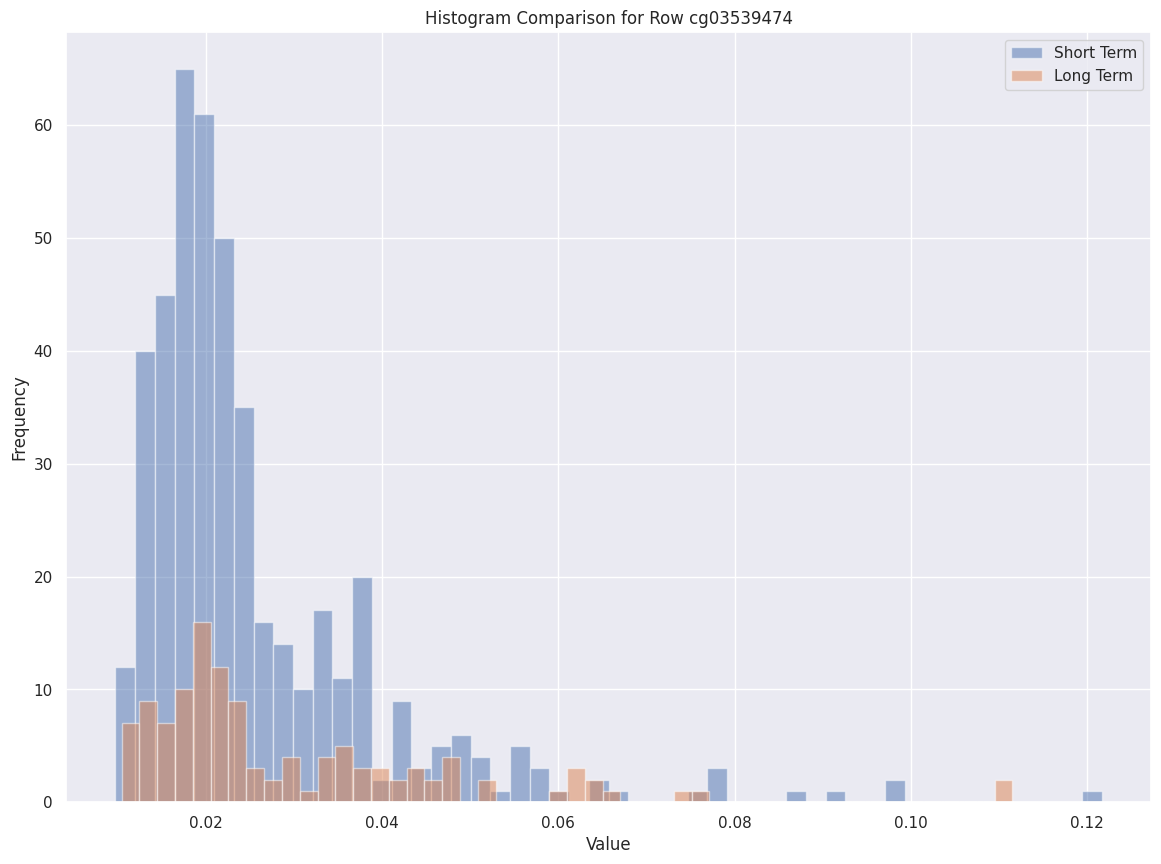

In [ ]:
row_name = 'cg03539474'
short_term_row = methyl_short_term_survive[methyl_short_term_survive.index == row_name]
long_term_row = methyl_long_term_survive[methyl_long_term_survive.index == row_name]
# Check if the row is present in both datasets
if short_term_row.empty or long_term_row.empty:
    print(f"Row with name '{row_name}' not found in one or both datasets.")
else:
    # Plot histograms for the selected row from both datasets
    plt.hist(short_term_row.T, label='Short Term', alpha=0.5, bins = 50)
    plt.hist(long_term_row.T, label='Long Term', alpha=0.5, bins = 50)

    # Add labels and legend
    plt.xlabel('Value')
    plt.ylabel('Frequency')
    plt.title(f'Histogram Comparison for Row {row_name}')
    plt.legend()

    # Show the plot
    plt.show()

I see a long tail, so maybe bootstrap with cutting edge would be also good test


In [ ]:
print(result_df_methyl.sort_values(by='P_Value'))

        Row_Name       P_Value  Mean_Long_Term  Std_Long_Term  \
842   cg26205432  5.980100e-29        0.903796   3.344752e-16   
920   cg20122491  3.039438e-06        0.013645   1.110144e-02   
2077  cg17543123  3.724474e-06        0.030672   1.946086e-02   
1431  cg00129774  9.824730e-06        0.019104   1.438364e-02   
1451  cg07915282  1.144069e-05        0.045997   3.719533e-02   
...          ...           ...             ...            ...   
988   cg07516225  9.946310e-03        0.039673   6.766261e-02   
2016  cg18801691  9.949947e-03        0.083700   7.208822e-02   
32    cg10274502  9.963446e-03        0.054332   4.174819e-02   
338   cg03539474  9.969702e-03        0.029534   1.840284e-02   
1374  cg07374928  9.972557e-03        0.897142   4.497830e-02   

      Mean_Short_Term  Std_Short_Term  
842          0.903796    1.111467e-16  
920          0.010486    4.553149e-03  
2077         0.024259    1.112022e-02  
1431         0.015310    5.585551e-03  
1451         0.0349

In [ ]:
methyl_long_term_survive.loc['cg20122491'].mean()

0.013644861302521008

In [ ]:
methyl_short_term_survive.head()

CASE_ID,TCGA-29-1696-01,TCGA-24-2267-01,TCGA-24-1843-01,TCGA-20-1682-01,TCGA-24-2254-01,TCGA-61-1728-01,TCGA-13-0723-01,TCGA-29-1781-01,TCGA-29-1705-01,TCGA-30-1887-01,TCGA-36-1570-01,TCGA-13-0720-01,TCGA-13-1487-01,TCGA-24-0980-01,TCGA-23-1122-01,TCGA-23-1027-01,TCGA-29-2434-01,TCGA-04-1646-01,TCGA-30-1866-01,TCGA-23-1030-01,TCGA-25-1627-01,TCGA-04-1652-01,TCGA-13-0760-01,TCGA-42-2589-01,TCGA-36-2544-01,TCGA-13-0768-01,TCGA-36-1577-01,TCGA-24-2261-01,TCGA-24-1471-01,TCGA-36-1581-01,TCGA-59-2363-01,TCGA-61-1911-01,TCGA-13-0724-01,TCGA-20-1684-01,TCGA-31-1951-01,TCGA-13-1411-01,TCGA-24-1425-01,TCGA-20-1683-01,TCGA-09-1669-01,TCGA-23-1107-01,TCGA-30-1718-01,TCGA-25-2399-01,TCGA-30-1892-01,TCGA-09-1665-01,TCGA-30-1880-01,TCGA-13-1500-01,TCGA-04-1332-01,TCGA-61-2087-01,TCGA-20-0990-01,TCGA-04-1343-01,TCGA-24-1424-01,TCGA-13-0714-01,TCGA-09-1674-01,TCGA-24-1567-01,TCGA-13-0755-01,TCGA-36-2540-01,TCGA-25-2404-01,TCGA-09-2043-01,TCGA-25-1323-01,TCGA-36-2538-01,TCGA-24-2297-01,TCGA-04-1517-01,TCGA-61-1995-01,TCGA-04-1335-01,TCGA-20-1687-01,TCGA-24-1470-01,TCGA-61-1743-01,TCGA-25-1322-01,TCGA-24-1845-01,TCGA-24-1558-01,TCGA-24-0970-01,TCGA-23-1117-01,TCGA-24-2029-01,TCGA-25-1635-01,TCGA-24-2271-01,TCGA-23-1809-01,TCGA-23-1031-01,TCGA-61-1727-01,TCGA-61-2613-01,TCGA-24-1564-01,TCGA-30-1859-01,TCGA-13-1491-01,TCGA-10-0926-01,TCGA-36-2534-01,TCGA-61-2109-01,TCGA-25-2409-01,TCGA-61-2017-01,TCGA-09-2056-01,TCGA-61-1906-01,TCGA-29-1711-01,TCGA-04-1655-01,TCGA-24-2030-01,TCGA-24-1614-01,TCGA-20-1685-01,TCGA-29-1774-01,TCGA-25-1313-01,TCGA-09-2054-01,TCGA-31-1955-01,TCGA-59-2354-01,TCGA-13-1504-01,TCGA-31-1946-01,TCGA-10-0931-01,TCGA-13-1510-01,TCGA-13-0894-01,TCGA-57-1584-01,TCGA-59-2350-01,TCGA-24-1103-01,TCGA-04-1648-01,TCGA-09-2053-01,TCGA-29-1699-01,TCGA-09-0367-01,TCGA-13-0795-01,TCGA-23-1110-01,TCGA-24-1428-01,TCGA-61-2009-01,TCGA-29-1691-01,TCGA-04-1361-01,TCGA-29-2428-01,TCGA-13-0801-01,TCGA-25-2393-01,TCGA-23-1021-01,TCGA-23-1026-01,TCGA-61-2612-01,TCGA-24-1920-01,TCGA-24-1474-01,TCGA-24-1426-01,TCGA-31-1956-01,TCGA-36-1568-01,TCGA-24-2260-01,TCGA-04-1519-01,TCGA-25-2391-01,TCGA-36-2545-01,TCGA-23-1120-01,TCGA-24-1565-01,TCGA-23-1022-01,TCGA-13-0893-01,TCGA-25-1634-01,TCGA-29-1702-01,TCGA-61-1741-01,TCGA-13-1506-01,TCGA-04-1362-01,TCGA-61-1721-01,TCGA-24-2288-01,TCGA-61-2012-01,TCGA-57-1585-01,TCGA-13-0916-01,TCGA-09-1670-01,TCGA-57-1994-01,TCGA-23-1123-01,TCGA-24-1552-01,TCGA-23-2643-01,TCGA-25-1626-01,TCGA-23-1111-01,TCGA-30-1853-01,TCGA-24-1548-01,TCGA-24-1419-01,TCGA-24-1846-01,TCGA-09-2044-01,TCGA-25-1631-01,TCGA-29-1695-01,TCGA-61-2008-01,TCGA-24-1549-01,TCGA-25-2401-01,TCGA-13-0802-01,TCGA-42-2593-01,TCGA-29-1761-01,TCGA-24-2023-01,TCGA-13-1485-01,TCGA-29-1783-01,TCGA-57-1582-01,TCGA-13-0803-01,TCGA-61-1722-01,TCGA-36-2547-01,TCGA-36-2537-01,TCGA-29-1707-01,TCGA-25-1623-01,TCGA-04-1364-01,TCGA-23-1121-01,TCGA-25-2042-01,TCGA-36-2543-01,TCGA-61-1913-01,TCGA-61-1917-01,TCGA-61-2110-01,TCGA-04-1342-01,TCGA-23-1024-01,TCGA-13-0727-01,TCGA-13-1512-01,TCGA-24-1923-01,TCGA-09-0365-01,TCGA-29-1768-01,TCGA-13-0765-01,TCGA-24-1105-01,TCGA-61-1914-01,TCGA-61-2002-01,TCGA-61-1907-01,TCGA-04-1356-01,TCGA-13-1408-01,TCGA-29-1771-01,TCGA-13-0766-01,TCGA-30-1856-01,TCGA-25-1325-01,TCGA-29-1769-01,TCGA-13-1817-01,TCGA-04-1341-01,TCGA-24-1849-01,TCGA-61-1899-01,TCGA-20-0991-01,TCGA-29-2429-01,TCGA-24-1417-01,TCGA-61-1733-01,TCGA-09-1673-01,TCGA-24-2281-01,TCGA-13-1501-01,TCGA-29-1777-01,TCGA-61-2101-01,TCGA-23-2645-01,TCGA-61-2096-01,TCGA-25-2392-01,TCGA-29-1776-01,TCGA-36-1575-01,TCGA-13-1483-01,TCGA-31-1953-01,TCGA-10-0934-01,TCGA-31-1944-01,TCGA-09-1659-01,TCGA-25-1312-01,TCGA-09-0364-01,TCGA-13-1511-01,TCGA-25-1317-01,TCGA-24-0975-01,TCGA-30-1869-01,TCGA-57-1583-01,TCGA-30-1855-01,TCGA-09-2055-01,TCGA-36-1569-01,TCGA-13-0920-01,TCGA-24-1557-01,TCGA-61-1901-01,TCGA-29-1704-01,TCGA-25-1321-01,TCGA-13-0791-01,TCGA-10-0930-01,TCGA-36-2551-01,TCGA-61-2102-01,TCGA-23-1124-01,TCGA-10-0925-01,TCGA-29-1701-01,TCGA-10-0933-01,TCGA-24-0979-01,TCGA-24-

## Gene gene_expression tranformation


In [ ]:
# Transpose df1
gene_expression_transposed = gene_expression.transpose()

In [ ]:
gene_expression_transposed = gene_expression_transposed.astype(float)

In [ ]:
needed_gene = gene_expression_transposed.sum()

In [ ]:
needed_gene != 0

ENSG00000000003.15     True
ENSG00000000005.6      True
ENSG00000000419.13     True
ENSG00000000457.14     True
ENSG00000000460.17     True
                      ...  
ENSG00000288669.1      True
ENSG00000288670.1      True
ENSG00000288671.1     False
ENSG00000288674.1      True
ENSG00000288675.1      True
Length: 60660, dtype: bool

In [ ]:
gene_expression_filtered = gene_expression_transposed.loc[:, needed_gene != 0]

In [ ]:
gene_expression_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 421 entries, TCGA-10-0933-01 to TCGA-24-1842-01
Columns: 57819 entries, ENSG00000000003.15 to ENSG00000288675.1
dtypes: float64(57819)
memory usage: 185.7+ MB


In [ ]:
# knn imputation transform for the horse colic dataset

from sklearn.impute import KNNImputer


# Get the values from the DataFrame
data = gene_expression_filtered.values

# Print total missing before imputation
print('Missing before imputation: %d' % pd.isnull(data).sum())

# Define imputer
imputer = KNNImputer()

# Fit on the dataset
imputer.fit(data)

# Transform the dataset
Xtrans = imputer.transform(data)

# Create a new DataFrame with the imputed values
column_names = gene_expression_filtered.columns
filled_dataframe_gene = pd.DataFrame(Xtrans, columns=column_names)
filled_dataframe_gene.index = gene_expression_filtered.index
# Print total missing after imputation
print('Missing after imputation: %d' % pd.isnull(Xtrans).sum())

Missing before imputation: 0
Missing after imputation: 0


In [ ]:
merged_df = gene_expression_filtered

In [ ]:
# Merge clinical_data with df1 based on the CASE_ID column
merged_df = pd.merge(gene_expression_transposed, clinical_data[['CASE_ID', 'Survival_Group']], left_index=True, right_on='CASE_ID')

merged_df = merged_df.set_index('CASE_ID')
# Create two new DataFrames based on Survival_Group
gene_expression_long_term_survive = merged_df[merged_df['Survival_Group'] == 'long_term_survive'].drop(columns=['Survival_Group'])
gene_expression_short_term_survive = merged_df[merged_df['Survival_Group'] == 'short_term_survive'].drop(columns=['Survival_Group'])
gene_expression_long_term_survive = gene_expression_long_term_survive.transpose()
gene_expression_short_term_survive = gene_expression_short_term_survive.transpose()
# Print the new DataFrames
# print("methyl_long_term_survive:")
# print(methyl_long_term_survive.head())

# print("\ndf1_short_term_survive:")
# print(methyl_short_term_survive.head())

In [ ]:
gene_expression_short_term_survive.info()

<class 'pandas.core.frame.DataFrame'>
Index: 60660 entries, ENSG00000000003.15 to ENSG00000288675.1
Columns: 331 entries, TCGA-10-0933-01 to TCGA-24-1842-01
dtypes: object(331)
memory usage: 153.6+ MB


In [ ]:
gene_expression_long_term_survive.info()

<class 'pandas.core.frame.DataFrame'>
Index: 60660 entries, ENSG00000000003.15 to ENSG00000288675.1
Data columns (total 88 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   TCGA-13-0886-01  60660 non-null  object
 1   TCGA-13-1505-01  60660 non-null  object
 2   TCGA-24-1104-01  60660 non-null  object
 3   TCGA-13-1410-01  60660 non-null  object
 4   TCGA-24-2020-01  60660 non-null  object
 5   TCGA-13-1407-01  60660 non-null  object
 6   TCGA-10-0927-01  60660 non-null  object
 7   TCGA-61-2094-01  60660 non-null  object
 8   TCGA-25-1633-01  60660 non-null  object
 9   TCGA-59-2348-01  60660 non-null  object
 10  TCGA-13-0885-01  60660 non-null  object
 11  TCGA-13-0913-01  60660 non-null  object
 12  TCGA-24-2289-01  60660 non-null  object
 13  TCGA-13-1488-01  60660 non-null  object
 14  TCGA-24-2036-01  60660 non-null  object
 15  TCGA-13-1497-01  60660 non-null  object
 16  TCGA-13-0890-01  60660 non-null  object
 17  TCGA-61

In [ ]:
gene_expression_short_term_survive = gene_expression_short_term_survive.astype(float)
gene_expression_long_term_survive = gene_expression_long_term_survive.astype(float)

In [ ]:
from scipy.stats import ttest_ind

# Assuming df1_long_term_survive and df1_short_term_survive are already defined

# Perform t-test for each row
results = []
alpha = 0.01

for index, row in gene_expression_long_term_survive.iterrows():
    t_stat, p_value = ttest_ind(row, gene_expression_short_term_survive.loc[index])
    mean_long_term = row.mean()
    mean_short_term = gene_expression_short_term_survive.loc[index].mean()
    std_long_term = row.std()
    std_short_term = gene_expression_short_term_survive.loc[index].std()

    # Store results if p-value is less than alpha
    if p_value < alpha:
        results.append([index, p_value, mean_long_term, std_long_term, mean_short_term, std_short_term])

# Create a DataFrame from the results
result_df_gene_expression = pd.DataFrame(results, columns=['Row_Name', 'P_Value', 'Mean_Long_Term', 'Std_Long_Term', 'Mean_Short_Term', 'Std_Short_Term'])

# Print the result DataFrame
print(result_df_gene_expression.sort_values(by='P_Value'))

               Row_Name   P_Value  Mean_Long_Term  Std_Long_Term  \
682   ENSG00000283209.1  0.000037        0.196244       0.246591   
663   ENSG00000279586.1  0.000045        0.070948       0.107315   
207   ENSG00000218483.1  0.000067        0.222283       0.580472   
147   ENSG00000200922.1  0.000074        0.124932       0.184675   
141   ENSG00000200528.1  0.000074        0.154244       0.356300   
..                  ...       ...             ...            ...   
61   ENSG00000145050.19  0.009931       38.400364      18.865433   
581   ENSG00000267547.1  0.009932        3.169706       1.621411   
52   ENSG00000141371.13  0.009944        0.309390       1.010482   
688   ENSG00000284730.1  0.009950        1.079806       2.020708   
618   ENSG00000273084.1  0.009990        1.530685       1.268189   

     Mean_Short_Term  Std_Short_Term  
682         0.112667        0.138551  
663         0.034057        0.063160  
207         0.075607        0.166516  
147         0.054095       

In [ ]:
print(result_df_gene_expression.sort_values(by='P_Value').head(100))

              Row_Name   P_Value  Mean_Long_Term  Std_Long_Term  \
682  ENSG00000283209.1  0.000037        0.196244       0.246591   
663  ENSG00000279586.1  0.000045        0.070948       0.107315   
207  ENSG00000218483.1  0.000067        0.222283       0.580472   
147  ENSG00000200922.1  0.000074        0.124932       0.184675   
141  ENSG00000200528.1  0.000074        0.154244       0.356300   
..                 ...       ...             ...            ...   
391  ENSG00000242266.3  0.001147        0.010284       0.035277   
703  ENSG00000285966.1  0.001162        0.102268       0.181201   
547  ENSG00000261747.3  0.001213        0.007473       0.029416   
743  ENSG00000288533.1  0.001221        0.076661       0.155126   
361  ENSG00000237605.2  0.001236        0.701635       0.689999   

     Mean_Short_Term  Std_Short_Term  
682         0.112667        0.138551  
663         0.034057        0.063160  
207         0.075607        0.166516  
147         0.054095        0.136018  


In [ ]:
gene_expression_short_term_survive.head()

CASE_ID,TCGA-10-0933-01,TCGA-23-1024-01,TCGA-29-1769-01,TCGA-61-1736-01,TCGA-61-1737-01,TCGA-25-1871-01,TCGA-29-1705-01,TCGA-13-0720-01,TCGA-61-1728-01,TCGA-WR-A838-01,TCGA-23-1122-01,TCGA-13-1487-01,TCGA-23-1027-01,TCGA-29-1774-01,TCGA-30-1866-01,TCGA-23-1030-01,TCGA-25-1627-01,TCGA-24-1564-01,TCGA-10-0926-01,TCGA-13-1510-01,TCGA-31-1956-01,TCGA-23-1028-01,TCGA-04-1655-01,TCGA-09-1661-01,TCGA-24-1416-01,TCGA-61-1911-01,TCGA-61-1995-01,TCGA-20-1684-01,TCGA-31-1951-01,TCGA-13-1411-01,TCGA-24-1425-01,TCGA-09-0367-01,TCGA-30-1718-01,TCGA-20-1687-01,TCGA-61-1743-01,TCGA-30-1892-01,TCGA-09-1665-01,TCGA-13-0801-01,TCGA-04-1343-01,TCGA-61-2092-01,TCGA-5X-AA5U-01,TCGA-61-1740-01,TCGA-09-1674-01,TCGA-61-2088-01,TCGA-24-1567-01,TCGA-23-2084-01,TCGA-OY-A56P-01,TCGA-24-1544-01,TCGA-04-1338-01,TCGA-36-1576-01,TCGA-13-0724-01,TCGA-09-1669-01,TCGA-20-1683-01,TCGA-23-1107-01,TCGA-13-0795-01,TCGA-25-2399-01,TCGA-29-1703-01,TCGA-24-1560-01,TCGA-61-1725-01,TCGA-25-1632-01,TCGA-59-2354-01,TCGA-24-1474-01,TCGA-24-1426-01,TCGA-13-1496-01,TCGA-04-1514-01,TCGA-36-1577-01,TCGA-59-2350-01,TCGA-29-A5NZ-01,TCGA-23-1120-01,TCGA-24-1565-01,TCGA-24-1423-01,TCGA-61-1900-01,TCGA-29-1781-01,TCGA-20-1685-01,TCGA-09-2054-01,TCGA-25-1313-01,TCGA-13-0760-01,TCGA-10-0931-01,TCGA-13-0768-01,TCGA-3P-A9WA-01,TCGA-24-1545-01,TCGA-36-1581-01,TCGA-29-1711-01,TCGA-23-1023-01,TCGA-29-2428-01,TCGA-24-1844-01,TCGA-25-1635-01,TCGA-OY-A56Q-01,TCGA-31-1946-01,TCGA-61-2109-01,TCGA-57-1584-01,TCGA-25-2409-01,TCGA-36-1568-01,TCGA-09-2056-01,TCGA-24-2261-01,TCGA-24-1471-01,TCGA-13-0893-01,TCGA-25-1634-01,TCGA-25-1870-01,TCGA-31-1959-01,TCGA-57-1993-01,TCGA-13-1409-01,TCGA-09-1668-01,TCGA-13-1477-01,TCGA-24-1418-01,TCGA-24-2288-01,TCGA-29-1784-01,TCGA-57-1585-01,TCGA-13-0916-01,TCGA-09-1670-01,TCGA-57-1994-01,TCGA-23-1123-01,TCGA-25-1321-01,TCGA-30-1853-01,TCGA-61-2016-01,TCGA-23-1109-01,TCGA-25-1631-01,TCGA-24-0975-01,TCGA-61-1738-01,TCGA-61-2008-01,TCGA-24-1549-01,TCGA-25-2401-01,TCGA-29-1761-01,TCGA-09-2045-01,TCGA-24-1551-01,TCGA-25-1316-01,TCGA-25-1320-01,TCGA-30-1891-01,TCGA-24-1434-01,TCGA-25-1623-01,TCGA-04-1364-01,TCGA-25-2042-01,TCGA-13-1512-01,TCGA-24-1923-01,TCGA-61-2102-01,TCGA-VG-A8LO-01,TCGA-04-1356-01,TCGA-29-1701-01,TCGA-29-1768-01,TCGA-57-1583-01,TCGA-13-0765-01,TCGA-24-2298-01,TCGA-29-1696-01,TCGA-24-2267-01,TCGA-13-0727-01,TCGA-20-1682-01,TCGA-13-0911-01,TCGA-20-0991-01,TCGA-57-1586-01,TCGA-24-1417-01,TCGA-24-1464-01,TCGA-25-2397-01,TCGA-13-1485-01,TCGA-30-1857-01,TCGA-25-2400-01,TCGA-57-1582-01,TCGA-23-1113-01,TCGA-24-1552-01,TCGA-25-2396-01,TCGA-25-1626-01,TCGA-29-1690-01,TCGA-25-1315-01,TCGA-09-1659-01,TCGA-25-2392-01,TCGA-25-1312-01,TCGA-29-1776-01,TCGA-24-1846-01,TCGA-09-2044-01,TCGA-13-1483-01,TCGA-31-1953-01,TCGA-10-0934-01,TCGA-23-1111-01,TCGA-59-2355-01,TCGA-04-1331-01,TCGA-36-1569-01,TCGA-24-1557-01,TCGA-61-2002-01,TCGA-61-1914-01,TCGA-13-0804-01,TCGA-13-1408-01,TCGA-24-0979-01,TCGA-24-2254-01,TCGA-04-1341-01,TCGA-24-1105-01,TCGA-61-1907-01,TCGA-61-2110-01,TCGA-25-1625-01,TCGA-24-1843-01,TCGA-24-1849-01,TCGA-04-1536-01,TCGA-24-2026-01,TCGA-61-1918-01,TCGA-24-1427-01,TCGA-24-2290-01,TCGA-24-1430-01,TCGA-24-1431-01,TCGA-13-0726-01,TCGA-24-2297-01,TCGA-04-1517-01,TCGA-25-1314-01,TCGA-13-1506-01,TCGA-24-2262-01,TCGA-13-0714-01,TCGA-09-2048-01,TCGA-29-1702-01,TCGA-25-1318-01,TCGA-24-2038-01,TCGA-09-0366-01,TCGA-61-1721-01,TCGA-61-2012-01,TCGA-24-1847-01,TCGA-24-1924-01,TCGA-61-2000-01,TCGA-25-2404-01,TCGA-10-0928-01,TCGA-04-1362-01,TCGA-13-0901-01,TCGA-24-0982-01,TCGA-29-1785-01,TCGA-24-1550-01,TCGA-09-0369-01,TCGA-29-1694-01,TCGA-25-1630-01,TCGA-13-0730-01,TCGA-20-0987-01,TCGA-61-1724-01,TCGA-29-1695-01,TCGA-29-1766-01,TCGA-25-1323-01,TCGA-13-1405-01,TCGA-25-1628-01,TCGA-59-2363-01,TCGA-04-1519-01,TCGA-09-2053-01,TCGA-61-1919-01,TCGA-24-0966-01,TCGA-20-1686-01,TCGA-23-1032-01,TCGA-04-1337-01,TCGA-04-1348-01,TCGA-25-2398-01,TCGA-23-1110-01,TCGA-24-1428-01,TCGA-61-2009-01,TCGA-10-0937-01,TCGA-24-1928-01,TCGA-04-1332-01,TCGA-24-2293-01,TCGA-25-1322-01,TCGA-23-

In [ ]:
gene_expression_long_term_survive.loc['ENSG00000000003.15'].mean()

19.49590909090909

In [ ]:

from scipy.stats import wilcoxon


In [ ]:
len(gene_expression_long_term_survive.T)

88

In [ ]:
for index, row in gene_expression_long_term_survive.iterrows():
    len_lt_surv = len(gene_expression_long_term_survive.T)


    # Randomly subsample the larger data set to match the smaller one
    gene_short = gene_expression_short_term_survive.T
    gene_short = np.random.choice(gene_short, size=88, replace=False)
    gene_expression_short_term_survive = gene_short.T

    # Now, both data sets have the same size, and you can perform the Wilcoxon test
    statistic, p_value = wilcoxon(df1, df2)
    t_stat, p_value = wilcoxon(row, gene_expression_short_term_survive.loc[index])
    mean_long_term = row.mean()
    mean_short_term = gene_expression_short_term_survive.loc[index].mean()
    std_long_term = row.std()
    std_short_term = gene_expression_short_term_survive.loc[index].std()

    # Store results if p-value is less than alpha
    if p_value < alpha:
        results.append([index, p_value, mean_long_term, std_long_term, mean_short_term, std_short_term])

# Create a DataFrame from the results
result_df_gene_expression = pd.DataFrame(results, columns=['Row_Name', 'P_Value', 'Mean_Long_Term', 'Std_Long_Term', 'Mean_Short_Term', 'Std_Short_Term'])

# Print the result DataFrame
print(result_df_gene_expression.sort_values(by='P_Value'))

ValueError: ignored

In [ ]:
gene_short = gene_expression_short_term_survive.transpose()

In [ ]:
gene_long = gene_expression_long_term_survive.transpose()

In [ ]:
gene_long.iloc[:5,:5]

,ENSG00000000003.15,ENSG00000000005.6,ENSG00000000419.13,ENSG00000000457.14,ENSG00000000460.17
CASE_ID,,,,,
TCGA-13-0886-01,37.0041,0.8018,60.7590,1.3454,0.8138
TCGA-13-1505-01,24.5643,0.6757,44.4372,2.3451,2.2605
TCGA-24-1104-01,6.9102,0.0122,42.9043,2.5410,0.7445
TCGA-13-1410-01,7.2882,0.2704,64.9749,2.0353,2.4423
TCGA-24-2020-01,36.6383,0.0279,70.9162,2.3990,5.0277


In [ ]:
def get_bootstrap(
    data_column_1,  # Numeric values of the first sample
    data_column_2,  # Numeric values of the second sample
    boot_it=500,  # Number of bootstrap subsamples
    statistic=np.mean,  # The statistic of interest
    bootstrap_conf_level=0.95  # Significance level
):
    boot_len = max([len(data_column_1), len(data_column_2)])
    boot_data = []
    for i in range(boot_it): # Extracting subsamples
        samples_1 = data_column_1.sample(
            boot_len,
            replace = True # Replacement parameter
        ).values

        samples_2 = data_column_2.sample(
            boot_len, # чтобы сохранить дисперсию, берем такой же размер выборки
            replace = True
        ).values

        boot_data.append(statistic(samples_1-samples_2))
    pd_boot_data = pd.DataFrame(boot_data)

    left_quant = (1 - bootstrap_conf_level)/2
    right_quant = 1 - (1 - bootstrap_conf_level) / 2
    quants = pd_boot_data.quantile([left_quant, right_quant])

    p_1 = norm.cdf(
        x = 0,
        loc = np.mean(boot_data),
        scale = np.std(boot_data)
    )
    p_2 = norm.cdf(
        x = 0,
        loc = -np.mean(boot_data),
        scale = np.std(boot_data)
    )
    p_value = min(p_1, p_2) * 2

    return p_value

In [ ]:
gene_long.isna()

In [ ]:
get_bootstrap(
    gene_long['ENSG00000029993.15'],  # числовые значения первой выборки
    gene_short['ENSG00000029993.15'], # числовые значения второй выборки
    boot_it = 500, # количество бутстрэп-подвыборок
    statistic = np.mean, # интересующая нас статистика
    bootstrap_conf_level = 0.95 # уровень значимости
)

6.411303815948103e-06

In [ ]:
clinical_data = clinical_data[clinical_data['CLINICAL_STAGE_NUM'] != 0]

In [ ]:
get_bootstrap(
    clinical_data[clinical_data['Survival_Group'] == 'short_term_survive']['CLINICAL_STAGE_NUM'],
    clinical_data[clinical_data['Survival_Group'] == 'long_term_survive']['CLINICAL_STAGE_NUM'], # числовые значения второй выборки
    boot_it = 1000, # количество бутстрэп-подвыборок
    statistic = np.mean, # интересующая нас статистика
    bootstrap_conf_level = 0.95 # уровень значимости
)

0.38479538014542736

In [ ]:
ttest_ind(clinical_data[clinical_data['Survival_Group'] == 'short_term_survive']['CLINICAL_STAGE_NUM'],
          clinical_data[clinical_data['Survival_Group'] == 'long_term_survive']['CLINICAL_STAGE_NUM'])

In [ ]:
clinical_data['Survival_Group'].unique()

In [ ]:
alpha = 0.05

In [ ]:
results = []
alpha = 0.05

for gene in result_df_gene_expression['Row_Name']:

    p_value = get_bootstrap(
      gene_long[gene],  # числовые значения первой выборки
      gene_short[gene], # числовые значения второй выборки
      boot_it = 500, # количество бутстрэп-подвыборок
      statistic = np.mean, # интересующая нас статистика
      bootstrap_conf_level = 0.95 # уровень значимости
    )
    # Store results if p-value is less than alpha
    results.append([gene, p_value])

# Create a DataFrame from the results
result_df_gene_bootstrap = pd.DataFrame(results, columns=['gene', 'P_Value'])

In [ ]:
results

In [ ]:
result_df_gene_bootstrap.sort_values(by='P_Value')

,gene,P_Value
208,ENSG00000219133.2,1.471414e-09
147,ENSG00000200922.1,4.859121e-09
393,ENSG00000242747.1,5.076969e-09
325,ENSG00000233254.1,1.009990e-08
682,ENSG00000283209.1,1.708109e-08
...,...,...
273,ENSG00000227983.1,7.872993e-03
296,ENSG00000230405.1,8.009283e-03
638,ENSG00000275662.1,8.914398e-03
454,ENSG00000251838.1,9.623519e-03


In [ ]:
result_df_gene_bootstrap['P_Value'] = result_df_gene_bootstrap['P_Value'].apply(lambda x: format(x, '.10f'))
print(result_df_gene_bootstrap.sort_values(by='P_Value'))

                  gene       P_Value
208  ENSG00000219133.2  0.0000000015
147  ENSG00000200922.1  0.0000000049
393  ENSG00000242747.1  0.0000000051
325  ENSG00000233254.1  0.0000000101
682  ENSG00000283209.1  0.0000000171
..                 ...           ...
273  ENSG00000227983.1  0.0078729927
296  ENSG00000230405.1  0.0080092835
638  ENSG00000275662.1  0.0089143985
454  ENSG00000251838.1  0.0096235187
649  ENSG00000278278.1  0.0103460898

[746 rows x 2 columns]


In [ ]:
result_df_gene_expression['Row_Name']

In [ ]:
methyl_long_term_survive.head()

CASE_ID,TCGA-29-1692-01,TCGA-25-1319-01,TCGA-04-1542-01,TCGA-24-1104-01,TCGA-13-0910-01,TCGA-20-0996-01,TCGA-24-2036-01,TCGA-13-0889-01,TCGA-13-0906-01,TCGA-61-2098-01,TCGA-10-0927-01,TCGA-13-2066-01,TCGA-13-1497-01,TCGA-29-1763-01,TCGA-59-2348-01,TCGA-04-1367-01,TCGA-13-0885-01,TCGA-25-1878-01,TCGA-29-2414-01,TCGA-13-0799-01,TCGA-13-1481-01,TCGA-29-1764-01,TCGA-24-2280-01,TCGA-23-1114-01,TCGA-13-1410-01,TCGA-23-2078-01,TCGA-13-1482-01,TCGA-13-1494-01,TCGA-24-1852-01,TCGA-13-0890-01,TCGA-13-1499-01,TCGA-24-2289-01,TCGA-04-1371-01,TCGA-24-2020-01,TCGA-23-2079-01,TCGA-13-1484-01,TCGA-23-2077-01,TCGA-13-1509-01,TCGA-24-1603-01,TCGA-13-0905-01,TCGA-13-0888-01,TCGA-61-2095-01,TCGA-29-2427-01,TCGA-09-2050-01,TCGA-13-0923-01,TCGA-29-1762-01,TCGA-13-0793-01,TCGA-13-1404-01,TCGA-61-2111-01,TCGA-13-1819-01,TCGA-13-0903-01,TCGA-13-0900-01,TCGA-29-1693-01,TCGA-13-1492-01,TCGA-13-1495-01,TCGA-24-1930-01,TCGA-23-1118-01,TCGA-24-1604-01,TCGA-25-1328-01,TCGA-13-1505-01,TCGA-09-1662-01,TCGA-24-1546-01,TCGA-13-0886-01,TCGA-04-1346-01,TCGA-24-2027-01,TCGA-59-2349-01,TCGA-04-1649-01,TCGA-09-1667-01,TCGA-04-1365-01,TCGA-09-2051-01,TCGA-24-1467-01,TCGA-61-1915-01,TCGA-04-1350-01,TCGA-24-1463-01,TCGA-09-1675-01,TCGA-13-1403-01,TCGA-13-0887-01,TCGA-23-1119-01,TCGA-13-0800-01,TCGA-29-1698-01,TCGA-13-2060-01,TCGA-13-0764-01,TCGA-25-1633-01,TCGA-04-1347-01,TCGA-13-0924-01,TCGA-61-2094-01,TCGA-13-1488-01,TCGA-13-0794-01,TCGA-13-2061-01,TCGA-13-0792-01,TCGA-13-2065-01,TCGA-13-1407-01,TCGA-13-2059-01,TCGA-13-0762-01,TCGA-13-0913-01,TCGA-29-1688-01,TCGA-29-2425-01,TCGA-23-2081-01,TCGA-09-1664-01,TCGA-04-1530-01,TCGA-13-2057-01,TCGA-13-0883-01,TCGA-24-1555-01,TCGA-13-1489-01,TCGA-24-1556-01,TCGA-13-0897-01,TCGA-13-0919-01,TCGA-13-1498-01,TCGA-61-2097-01,TCGA-13-0899-01,TCGA-13-1507-01,TCGA-13-0884-01,TCGA-04-1351-01,TCGA-13-0797-01,TCGA-59-2351-01,TCGA-61-2104-01,TCGA-09-2049-01,TCGA-13-0908-01,TCGA-13-0891-01
cg04672450,0.017129,0.003406,0.010102,0.012643,0.011686,0.009546,0.009992,0.014121,0.010917,0.007944,0.017123,0.014119,0.009918,0.007964,0.007357,0.006016,0.021133,0.009079,0.010837,0.017181,0.012220,0.008966,0.016748,0.009730,0.005261,0.007257,0.021519,0.006332,0.012675,0.011538,0.012562,0.009188,0.006177,0.007829,0.008044,0.017752,0.006070,0.014089,0.007301,0.008491,0.010101,0.007968,0.009511,0.009588,0.009772,0.009261,0.015993,0.005343,0.007531,0.012072,0.009785,0.007084,0.012255,0.015121,0.010968,0.005698,0.009469,0.007269,0.006441,0.009370,0.008802,0.008655,0.022958,0.008303,0.008005,0.009447,0.008937,0.013335,0.007134,0.007837,0.011625,0.006278,0.005648,0.005961,0.008305,0.005326,0.014597,0.010036,0.022431,0.009436,0.016552,0.017107,0.011337,0.012527,0.016995,0.007930,0.012562,0.014589,0.014974,0.011405,0.028637,0.006535,0.018606,0.025514,0.023663,0.012086,0.015747,0.007960,0.008549,0.011303,0.011735,0.014651,0.007459,0.013088,0.008746,0.014084,0.020257,0.012024,0.011338,0.017697,0.013634,0.006402,0.005058,0.012112,0.018399,0.008768,0.009645,0.008781,0.014466
cg14324200,0.074124,0.108184,0.229084,0.025516,0.018110,0.018316,0.013575,0.047122,0.090257,0.053645,0.037660,0.077102,0.062991,0.027480,0.034557,0.064831,0.038476,0.013751,0.041076,0.022731,0.027509,0.026472,0.143922,0.061003,0.430852,0.023177,0.695249,0.023385,0.017357,0.056996,0.031163,0.027535,0.434037,0.010928,0.017685,0.076797,0.008604,0.231818,0.188484,0.624142,0.116298,0.020376,0.019179,0.198742,0.018515,0.183021,0.108997,0.061345,0.254241,0.022880,0.078239,0.148096,0.026564,0.087023,0.198014,0.011795,0.022847,0.010034,0.033235,0.020327,0.028710,0.048451,0.027634,0.012908,0.026731,0.037686,0.011758,0.419232,0.039369,0.587047,0.010736,0.008175,0.006678,0.271437,0.086031,0.378072,0.116161,0.021392,0.018437,0.538380,0.035204,0.013499,0.020867,0.062289,0.022221,0.031608,0.021578,0.013598,0.013050,0.011305,0.017556,0.007296,0.041562,0.015714,0.039768,0.011949,0.030309,0.495166,0.024055,0.038686,0.031979,0.014350,0.244679,0.028242,0.198737,0.082094,0.024173,0.019466,0.011009,0.015420,0.028

In [ ]:
methyl_long = methyl_long_term_survive.transpose()
methyl_short = methyl_short_term_survive.transpose()

In [ ]:
methyl_short.iloc[:5,:5]

,cg04672450,cg14324200,cg04485075,cg21832150,cg02397514
CASE_ID,,,,,
TCGA-29-1696-01,0.007975,0.013202,0.016113,0.016324,0.007484
TCGA-24-2267-01,0.022397,0.020087,0.018354,0.018255,0.011611
TCGA-24-1843-01,0.008652,0.027440,0.013653,0.015268,0.018468
TCGA-20-1682-01,0.010599,0.292841,0.021156,0.018232,0.013304
TCGA-24-2254-01,0.015251,0.011705,0.033398,0.033414,0.018066


In [ ]:
results = []
alpha = 0.05

for gene in result_df_methyl['Row_Name']:

    p_value = get_bootstrap(
      methyl_long[gene],  # числовые значения первой выборки
      methyl_short[gene], # числовые значения второй выборки
      boot_it = 500, # количество бутстрэп-подвыборок
      statistic = np.mean, # интересующая нас статистика
      bootstrap_conf_level = 0.95 # уровень значимости
    )
    # Store results if p-value is less than alpha
    results.append([gene, p_value])

# Create a DataFrame from the results
result_df_methyl_bootstrap = pd.DataFrame(results, columns=['gene', 'P_Value'])

/usr/local/lib/python3.10/dist-packages/scipy/stats/_distn_infrastructure.py:2066: RuntimeWarning: invalid value encountered in divide
  x = np.asarray((x - loc)/scale, dtype=dtyp)


In [ ]:
result_df_methyl_bootstrap.sort_values(by='P_Value')

,gene,P_Value
2077,cg17543123,5.797721e-10
2246,cg17111669,1.421429e-09
1105,cg26478992,1.502461e-09
369,cg14800883,1.602745e-09
130,cg05795157,2.102783e-09
...,...,...
1771,cg01979004,5.715029e-03
1822,cg09438266,6.122957e-03
538,cg04836786,6.187499e-03
1304,cg25059436,7.219260e-03


In [ ]:
result_df_methyl_bootstrap['P_Value'] = result_df_gene_bootstrap['P_Value'].apply(lambda x: format(x, '.10f'))
print(result_df_methyl_bootstrap.sort_values(by='P_Value').head(20))

NameError: ignored

In [ ]:
print(result_df_methyl_bootstrap.sort_values(by='P_Value').head(20))

            gene       P_Value
999   cg00047050  0.0000000002
1642  cg17111669  0.0000000002
1521  cg17543123  0.0000000004
1535  cg03064400  0.0000000008
1677  cg06722792  0.0000000015
373   cg25040783  0.0000000021
772   cg20379125  0.0000000026
101   cg05795157  0.0000000046
689   cg03429034  0.0000000057
1099  cg16547450  0.0000000069
1054  cg10878896  0.0000000077
1119  cg26516764  0.0000000162
279   cg08587820  0.0000000181
1615  cg09282338  0.0000000183
25    cg02612026  0.0000000206
1103  cg00432979  0.0000000237
1641  cg11399590  0.0000000250
337   cg16129988  0.0000000298
846   cg19324791  0.0000000311
343   cg26475097  0.0000000342


In [ ]:
result_df_methyl_bootstrap.merge(result_df_methyl, how = 'left',  left_on = 'gene', right_on = 'Row_Name')

,gene,P_Value_x,Row_Name,P_Value_y,Mean_Long_Term,Std_Long_Term,Mean_Short_Term,Std_Short_Term
0,cg04485075,0.000008,cg04485075,0.004746,0.024424,0.013740,0.020845,0.011809
1,cg08067365,0.000016,cg08067365,0.001265,0.029580,0.018354,0.025362,0.010597
2,cg00262415,0.000350,cg00262415,0.008313,0.023297,0.012475,0.020798,0.008040
3,cg10164137,0.000152,cg10164137,0.004485,0.035909,0.044698,0.026380,0.028228
4,cg03716942,0.000102,cg03716942,0.006124,0.020662,0.010880,0.018150,0.008231
...,...,...,...,...,...,...,...,...
2346,cg03465847,0.000074,cg03465847,0.002274,0.051053,0.141013,0.022643,0.070308
2347,cg04507972,0.000016,cg04507972,0.000367,0.041900,0.107413,0.019442,0.040150
2348,cg18511445,0.000029,cg18511445,0.001838,0.056526,0.076977,0.037689,0.052311
2349,cg02232922,0.000096,cg02232922,0.007935,0.055900,0.032662,0.048311,0.026111


In [ ]:
result_df_methyl_bootstrap

NameError: ignored

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#csv_path = '/content/drive/My Drive/Python_projects/OvarianCancer/Results/results_of_methyl.csv'

In [ ]:
# result_df_gene_bootstrap.merge(result_df_methyl, how = 'left',  left_on = 'gene', right_on = 'Row_Name'
#   ).to_csv(csv_path, index=True)

In [ ]:
methyl_long.to_csv('/content/drive/My Drive/Python_projects/OvarianCancer/Results/methyl_long.csv', index=True)
methyl_short.to_csv('/content/drive/My Drive/Python_projects/OvarianCancer/Results/methyl_short.csv', index=True)

In [ ]:
gene_long.to_csv('/content/drive/My Drive/Python_projects/OvarianCancer/Results/gene_long.csv', index=True)
gene_short.to_csv('/content/drive/My Drive/Python_projects/OvarianCancer/Results/gene_short.csv', index=True)

In [ ]:
result_df_gene_expression.to_csv('/content/drive/My Drive/Python_projects/OvarianCancer/Results/result_df_gene_expression.csv', index=True)

In [ ]:
result_df_methyl.to_csv('/content/drive/My Drive/Python_projects/OvarianCancer/Results/result_df_methyl.csv', index=True)

In [ ]:
result_df_methyl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2351 entries, 0 to 2350
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Row_Name         2351 non-null   object 
 1   P_Value          2351 non-null   float64
 2   Mean_Long_Term   2351 non-null   float64
 3   Std_Long_Term    2351 non-null   float64
 4   Mean_Short_Term  2351 non-null   float64
 5   Std_Short_Term   2351 non-null   float64
dtypes: float64(5), object(1)
memory usage: 110.3+ KB
